# A/B Testing in Two-Sided Markets: Experiments

This notebook generates all figures and tables for the experiments section.

## Contents
1. Core Functions (market model, dynamics, estimators)
2. Test Scenarios (40 scenarios across 6 categories)
3. Figure Generation
4. Table Generation

In [48]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import math

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.labelsize'] = 12
matplotlib.rcParams['axes.titlesize'] = 12
matplotlib.rcParams['legend.fontsize'] = 9
matplotlib.rcParams['figure.dpi'] = 150
e = math.e

## 1. Core Functions

In [49]:
def gradient(s, P, epsilon, taus, mu, rho, phi):
    """Gradient update to the available listing state."""
    probs = P * s.reshape(1, -1)
    probs = probs / (epsilon + probs.sum(axis=1)).reshape(-1, 1)
    ds = (rho - s) * taus - mu * (probs * phi.reshape(-1, 1)).sum(axis=0)
    return ds


def dynamics(P, epsilon, taus, mu, rho, phi, *, eta=1e-2, tol=1e-4, n_iters=10000):
    """Simulate market dynamics to find steady state."""
    s = np.zeros((n_iters, P.shape[1]))
    s[0] = rho
    converged = False
    for t in np.arange(1, n_iters):
        ds = gradient(s[t-1], P, epsilon, taus, mu, rho, phi)
        s[t] = s[t-1] + eta * ds
        if np.max(np.abs(ds)) < tol:
            converged = True
            break
    if not converged:
        warnings.warn('Simulation did not converge, increase n_iters')
    return s[:t+1]


def rate_of_booking(s, P, epsilon, mu, phi):
    """Compute rate of booking at steady state."""
    probs = P * s.reshape(1, -1)
    probs = probs / (epsilon + probs.sum(axis=1)).reshape(-1, 1)
    Q = mu * (phi @ probs @ np.ones(probs.shape[1]))
    return Q


def rate_of_booking_exp(s, P, epsilon, mu, phi):
    """Compute rate of booking for experiment (2x2 grid)."""
    probs = P * s.reshape(1, -1)
    probs = probs / (epsilon + probs.sum(axis=1)).reshape(-1, 1)
    Q = np.zeros((2, 2))
    n_c = P.shape[0] // 2
    n_l = P.shape[1] // 2
    for i in range(2):
        for j in range(2):
            phi_i = phi[i * n_c : (i+1) * n_c]
            probs_ij = probs[i * n_c : (i+1) * n_c, j * n_l : (j+1) * n_l]
            Q[i, j] = mu * (phi_i @ probs_ij @ np.ones(probs_ij.shape[1]))
    return Q


def get_experiment_params(aC, aL, Ptilde, P, epsilon, taus, mu, rho, phi):
    """Create experiment parameters for two-sided randomization."""
    P_exp = np.block([[P, P], [P, Ptilde]])
    epsilon_exp = np.block([epsilon, epsilon])
    taus_exp = np.block([taus, taus])
    rho_exp = np.block([(1 - aL) * rho, aL * rho])
    phi_exp = np.block([(1 - aC) * phi, aC * phi])
    return P_exp, epsilon_exp, taus_exp, mu, rho_exp, phi_exp


def bias_analysis(aC, aL, Ptilde, P, epsilon, taus, mu, rho, phi):
    """Main function to compare estimators."""
    # Global control
    s = dynamics(P, epsilon, taus, mu, rho, phi)
    Qcontrol = rate_of_booking(s[-1], P, epsilon, mu, phi)
    # Global Treatment
    s = dynamics(Ptilde, epsilon, taus, mu, rho, phi)
    Qtreatment = rate_of_booking(s[-1], Ptilde, epsilon, mu, phi)
    # Two-Sided Randomization Experiment
    params_exp = get_experiment_params(aC, aL, Ptilde, P, epsilon, taus, mu, rho, phi)
    P_exp, epsilon_exp, taus_exp, mu_exp, rho_exp, phi_exp = params_exp
    s = dynamics(P_exp, epsilon_exp, taus_exp, mu, rho_exp, phi_exp)
    Q = rate_of_booking_exp(s[-1], P_exp, epsilon_exp, mu, phi_exp)
    GTE_TSR = Q[1, 1] / (aC * aL) - (Q[0, 1] + Q[1, 0] + Q[0, 0]) / (1 - aC * aL)
    return Q, Qcontrol, Qtreatment, GTE_TSR, Qtreatment - Qcontrol


def compute_all_estimators(Q, aC, aL, GTE_true, mu, tau, lambda_tau_ratio):
    """Compute all estimators and their biases."""
    GTE_TSR = Q[1, 1] / (aC * aL) - (Q[0, 1] + Q[1, 0] + Q[0, 0]) / (1 - aC * aL)
    GTE_DD = (Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL))
    GTE_D = Q[1, 1] / (aC * aL) - Q[0, 0] / ((1 - aC) * (1 - aL))
    GTE_CR = Q[1, 1] / (aC * aL) - Q[0, 1] / ((1 - aC) * aL)
    GTE_LR = Q[1, 1] / (aC * aL) - Q[1, 0] / (aC * (1 - aL))
    beta = np.exp(-lambda_tau_ratio)
    Q00_norm = Q[0, 0] / ((1 - aC) * (1 - aL))
    Q01_norm = Q[0, 1] / ((1 - aC) * aL)
    Q10_norm = Q[1, 0] / (aC * (1 - aL))
    Q11_norm = Q[1, 1] / (aC * aL)

    GTE_TSRI1 = beta * (Q11_norm - Q01_norm - (1 - beta) * (Q00_norm - Q01_norm)) + (1 - beta) * (Q11_norm - Q10_norm - beta * (Q00_norm - Q10_norm))
    GTE_TSRI2 = beta * (Q11_norm - Q01_norm - 2 * (1 - beta) * (Q00_norm - Q01_norm)) + (1 - beta) * (Q11_norm - Q10_norm - 2 * beta * (Q00_norm - Q10_norm))


    return {
        'GTE_TSR': GTE_TSR,
        'GTE_DD': GTE_DD,
        # 'GTE_D': GTE_D,
        'GTE_CR': GTE_CR,
        'GTE_LR': GTE_LR,
        'GTE_true': GTE_true,
        'bias_TSR': GTE_TSR - GTE_true,
        'bias_DD': GTE_DD - GTE_true,
        # 'bias_D': GTE_D - GTE_true,
        'bias_CR': GTE_CR - GTE_true,
        'bias_LR': GTE_LR - GTE_true,
        'GTE_TSRI1': GTE_TSRI1,
        'GTE_TSRI2': GTE_TSRI2,
        'bias_TSRI1': GTE_TSRI1 - GTE_true,
        'bias_TSRI2': GTE_TSRI2 - GTE_true,
    }


def run_scenario(name, P, Ptilde, epsilon, taus, mu, rho, phi, aC=0.5, aL=0.5, verbose=True):
    """Run a single scenario and return results."""
    Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(aC, aL, Ptilde, P, epsilon, taus, mu, rho, phi)
    tau = np.mean(taus)
    lambda_tau_ratio = mu / tau
    results = compute_all_estimators(Q, aC, aL, GTE_true, mu, tau, lambda_tau_ratio)

    results['name'] = name
    results['n_customers'] = len(phi)
    results['n_listings'] = len(rho)
    results['mu'] = mu
    results['aC'] = aC
    results['aL'] = aL
    results['lambda_tau_ratio'] = lambda_tau_ratio

    if verbose:
        print(f"\nSCENARIO: {name}")
        print(f"Market: n_customers={len(phi)}, n_listings={len(rho)}, mu={mu:.2f}")
        print(f"Experiment: aC={aC:.2f}, aL={aL:.2f}")
        print(f"\nTrue GTE: {GTE_true:.6f}")
        print(f"\n{'Estimator':<10} {'Estimate':<12} {'Bias':<12} {'Rel.Bias %':<12}")
        print(f"{'-'*46}")
        for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
            est_val = results[f'GTE_{est}']
            bias_val = results[f'bias_{est}']
            rel_bias = 100 * bias_val / abs(GTE_true) if abs(GTE_true) > 1e-8 else float('inf')
            print(f"{est:<10} {est_val:<12.6f} {bias_val:<12.6f} {rel_bias:<12.1f}")

    return results

## 2. Test Scenarios (40 total)

In [50]:
# All 40 scenario definitions

def scenario_1():
    """Uniform improvement (+0.1 to all P_ij)"""
    P = np.array([[0.1, 0.9], [0.9, 0.1], [0.2, 0.8]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.2, 0.8])
    mu = 0.3
    rho = np.array([0.3, 0.7])
    phi = np.array([0.3, 0.3, 0.4])
    return "Uniform improvement (+0.1 to all P_ij)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_2():
    """Single cell change"""
    P = np.array([[0.1, 0.9], [0.9, 0.1], [0.2, 0.8]])
    Ptilde = P.copy()
    Ptilde[0, 0] = 0.5
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.2, 0.8])
    mu = 0.3
    rho = np.array([0.3, 0.7])
    phi = np.array([0.3, 0.3, 0.4])
    return "Single cell change (P[0,0]: 0.1 -> 0.5)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_3():
    """Treatment helps some, hurts others"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.array([[0.6, 0.3], [0.8, 0.2], [0.7, 0.2]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.5, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Treatment helps listing type 1, hurts type 2", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_4():
    """Small varying effect by listing type"""
    P = np.array([[0.3, 0.7], [0.7, 0.3], [0.4, 0.6]])
    Ptilde = P.copy()
    Ptilde[:, 0] += 0.05
    Ptilde[:, 1] += 0.15
    Ptilde = np.clip(Ptilde, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.3, 0.6])
    mu = 0.3
    rho = np.array([0.4, 0.6])
    phi = np.array([0.3, 0.3, 0.4])
    return "Small varying effect by listing type (+0.05 vs +0.15)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_5():
    """Small varying effect by customer type"""
    P = np.array([[0.3, 0.7], [0.5, 0.5], [0.4, 0.6]])
    Ptilde = P.copy()
    Ptilde[0, :] += 0.2
    Ptilde[1, :] += 0.05
    Ptilde[2, :] += 0.1
    Ptilde = np.clip(Ptilde, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.35
    rho = np.array([0.5, 0.5])
    phi = np.array([0.2, 0.5, 0.3])
    return "Small varying effect by customer type", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_6():
    """High supply, low demand"""
    P = np.array([[0.3, 0.7], [0.7, 0.3], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.15, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([2.0, 2.0])
    mu = 0.1
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "High supply, low demand (taus=2.0, mu=0.1)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_7():
    """Low supply, high demand"""
    P = np.array([[0.3, 0.7], [0.7, 0.3], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.15, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.1, 0.1])
    mu = 2.0
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Low supply, high demand (taus=0.1, mu=2.0)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_8():
    """Many customer types"""
    n_customers, n_listings = 10, 2
    np.random.seed(42)
    P = np.random.uniform(0.2, 0.8, (n_customers, n_listings))
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.ones(n_customers) * 0.2
    taus = np.array([0.4, 0.6])
    mu = 0.5
    rho = np.array([0.4, 0.6])
    phi = np.ones(n_customers) / n_customers
    return "Many customer types (10 customers, 2 listings)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_9():
    """Many listing types"""
    n_customers, n_listings = 2, 10
    np.random.seed(43)
    P = np.random.uniform(0.2, 0.8, (n_customers, n_listings))
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.ones(n_customers) * 0.2
    taus = np.random.uniform(0.2, 0.8, n_listings)
    mu = 0.5
    rho = np.ones(n_listings) / n_listings
    phi = np.array([0.6, 0.4])
    return "Many listing types (2 customers, 10 listings)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_10():
    """Sparse market"""
    P = np.array([[0.9, 0.05, 0.01], [0.02, 0.85, 0.03], [0.01, 0.02, 0.92]])
    Ptilde = np.array([[0.95, 0.1, 0.02], [0.05, 0.9, 0.05], [0.02, 0.05, 0.95]])
    epsilon = np.array([0.1, 0.1, 0.1])
    taus = np.array([0.3, 0.4, 0.5])
    mu = 0.4
    rho = np.array([0.3, 0.3, 0.4])
    phi = np.array([0.3, 0.3, 0.4])
    return "Sparse market (specialized customer-listing matching)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_11():
    """Dense market"""
    P = np.array([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]])
    Ptilde = np.array([[0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.4, 0.4])
    mu = 0.4
    rho = np.array([0.33, 0.33, 0.34])
    phi = np.array([0.33, 0.33, 0.34])
    return "Dense market (uniform moderate matching)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_12():
    """One dominant customer type"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.9, 0.05, 0.05])
    return "One dominant customer type (90% type 0)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_13():
    """One dominant listing type"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.9, 0.1])
    phi = np.array([0.3, 0.3, 0.4])
    return "One dominant listing type (90% type 0)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_14():
    """Treatment helps rare listings"""
    P = np.array([[0.3, 0.7], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = P.copy()
    Ptilde[:, 0] += 0.3
    Ptilde[:, 1] += 0.02
    Ptilde = np.clip(Ptilde, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.3, 0.5])
    mu = 0.4
    rho = np.array([0.1, 0.9])
    phi = np.array([0.3, 0.3, 0.4])
    return "Treatment mainly helps rare listing type", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_15():
    """Treatment helps rare customers"""
    P = np.array([[0.3, 0.7], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = P.copy()
    Ptilde[0, :] += 0.4
    Ptilde[1, :] += 0.02
    Ptilde[2, :] += 0.02
    Ptilde = np.clip(Ptilde, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.05, 0.45, 0.5])
    return "Treatment mainly helps rare customer type", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_16():
    """Asymmetric split"""
    P = np.array([[0.3, 0.7], [0.7, 0.3], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.15, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.4, 0.6])
    phi = np.array([0.3, 0.3, 0.4])
    return "Asymmetric split (aC=0.2, aL=0.8)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.2, 0.8

def scenario_17():
    """Very small effect"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = P + 0.01
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Very small uniform effect (+0.01)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_18():
    """Very large effect"""
    P = np.array([[0.1, 0.2], [0.2, 0.1], [0.15, 0.15]])
    Ptilde = np.array([[0.7, 0.8], [0.8, 0.7], [0.75, 0.75]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Very large effect (P goes from ~0.15 to ~0.75)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_19():
    """Heterogeneous turnover"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.1, 2.0])
    mu = 0.5
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Heterogeneous turnover (taus=[0.1, 2.0])", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_20():
    """Heterogeneous outside options"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.05, 0.2, 0.8])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Heterogeneous outside options (eps=[0.05, 0.2, 0.8])", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_21():
    """Treatment hurts"""
    P = np.array([[0.6, 0.7], [0.7, 0.6], [0.65, 0.65]])
    Ptilde = np.array([[0.4, 0.5], [0.5, 0.4], [0.45, 0.45]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Treatment HURTS (negative GTE)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_22():
    """Very low outside option (captive customers)"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.01, 0.02, 0.01])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Very low outside option (captive customers, eps~0.01)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_23():
    """Interaction effect: treatment varies by both customer AND listing type"""
    P = np.array([[0.3, 0.5], [0.5, 0.3], [0.4, 0.4]])
    Ptilde = np.array([
        [0.7, 0.4],
        [0.45, 0.35],
        [0.3, 0.8]
    ])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Interaction effect (treatment varies by customer-listing pair)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_24():
    """Column permutation"""
    P = np.array([[0.3, 0.7], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.array([[0.7, 0.3], [0.4, 0.6], [0.5, 0.5]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.3, 0.6])
    mu = 0.4
    rho = np.array([0.4, 0.6])
    phi = np.array([0.3, 0.3, 0.4])
    return "Column permutation effect (swap listing preferences)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_25():
    """Extreme scarcity"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.15, 0, 1)
    epsilon = np.array([0.1, 0.1, 0.1])
    taus = np.array([0.05, 0.05])
    mu = 5.0
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Extreme scarcity (taus=0.05, mu=5.0)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_26():
    """Diagonal only"""
    P = np.array([[0.3, 0.5, 0.4], [0.4, 0.3, 0.5], [0.5, 0.4, 0.3]])
    Ptilde = P.copy()
    np.fill_diagonal(Ptilde, [0.7, 0.7, 0.7])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.4, 0.4])
    mu = 0.4
    rho = np.array([0.33, 0.33, 0.34])
    phi = np.array([0.33, 0.33, 0.34])
    return "Treatment only affects diagonal (specialization)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_27():
    """Off-diagonal only"""
    P = np.array([[0.7, 0.3, 0.3], [0.3, 0.7, 0.3], [0.3, 0.3, 0.7]])
    Ptilde = np.array([[0.7, 0.5, 0.5], [0.5, 0.7, 0.5], [0.5, 0.5, 0.7]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.4, 0.4])
    mu = 0.4
    rho = np.array([0.33, 0.33, 0.34])
    phi = np.array([0.33, 0.33, 0.34])
    return "Treatment only affects off-diagonal (cross-matching)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_28():
    """Large market 5x5"""
    n = 5
    np.random.seed(44)
    P = np.random.uniform(0.3, 0.7, (n, n))
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.ones(n) * 0.2
    taus = np.random.uniform(0.3, 0.7, n)
    mu = 0.5
    rho = np.ones(n) / n
    phi = np.ones(n) / n
    return "Large market 5x5 with uniform effect", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_29():
    """Power-law customers"""
    P = np.array([[0.4, 0.6], [0.5, 0.5], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.12, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.6, 0.25, 0.1, 0.05])
    return "Power-law customer distribution", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_30():
    """Power-law listings"""
    P = np.array([[0.4, 0.5, 0.6, 0.5], [0.5, 0.6, 0.4, 0.5], [0.6, 0.4, 0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.4, 0.5, 0.5])
    mu = 0.4
    rho = np.array([0.6, 0.25, 0.1, 0.05])
    phi = np.array([0.33, 0.33, 0.34])
    return "Power-law listing distribution", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_31():
    """Multiplicative effect"""
    P = np.array([[0.2, 0.4], [0.5, 0.3], [0.35, 0.35]])
    Ptilde = np.clip(P * 1.3, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Multiplicative effect (P * 1.3)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_32():
    """Only weak matches improve"""
    P = np.array([[0.2, 0.8], [0.8, 0.2], [0.5, 0.5]])
    Ptilde = P.copy()
    Ptilde[P < 0.5] = P[P < 0.5] + 0.3
    Ptilde = np.clip(Ptilde, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Only weak matches (P<0.5) improve", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_33():
    """Only strong matches improve"""
    P = np.array([[0.2, 0.7], [0.7, 0.2], [0.5, 0.5]])
    Ptilde = P.copy()
    Ptilde[P >= 0.5] = np.clip(P[P >= 0.5] + 0.15, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.5])
    mu = 0.4
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Only strong matches (P>=0.5) improve", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_34():
    """Single listing type"""
    P = np.array([[0.4], [0.5], [0.6]])
    Ptilde = np.array([[0.5], [0.6], [0.7]])
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.5])
    mu = 0.4
    rho = np.array([1.0])
    phi = np.array([0.3, 0.3, 0.4])
    return "Single listing type (m=1)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_35():
    """Single customer type"""
    P = np.array([[0.4, 0.5, 0.6]])
    Ptilde = np.array([[0.5, 0.6, 0.7]])
    epsilon = np.array([0.2])
    taus = np.array([0.3, 0.4, 0.5])
    mu = 0.4
    rho = np.array([0.3, 0.3, 0.4])
    phi = np.array([1.0])
    return "Single customer type (n=1)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_36():
    """Extreme demand constraint"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([0.02, 0.02])
    mu = 10.0
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Extreme demand constraint (taus=0.02, mu=10.0)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_37():
    """Extreme supply constraint"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.1, 0, 1)
    epsilon = np.array([0.2, 0.2, 0.2])
    taus = np.array([5.0, 5.0])
    mu = 0.01
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Extreme supply constraint (taus=5.0, mu=0.01)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_38():
    """Outside option dominates"""
    P = np.array([[0.4, 0.6], [0.6, 0.4], [0.5, 0.5]])
    Ptilde = np.clip(P + 0.15, 0, 1)
    epsilon = np.array([3.0, 2.5, 4.0])
    taus = np.array([0.4, 0.5])
    mu = 0.5
    rho = np.array([0.5, 0.5])
    phi = np.array([0.3, 0.3, 0.4])
    return "Outside option dominates (epsilon=[3.0, 2.5, 4.0])", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_39():
    """Treatment creates new matches"""
    P = np.array([[0.8, 0.0, 0.0], [0.0, 0.8, 0.0], [0.0, 0.0, 0.8], [0.3, 0.3, 0.3]])
    Ptilde = np.array([[0.8, 0.3, 0.2], [0.3, 0.8, 0.3], [0.2, 0.3, 0.8], [0.4, 0.4, 0.4]])
    epsilon = np.array([0.2, 0.2, 0.2, 0.2])
    taus = np.array([0.4, 0.4, 0.4])
    mu = 0.5
    rho = np.array([0.33, 0.33, 0.34])
    phi = np.array([0.25, 0.25, 0.25, 0.25])
    return "Treatment creates new matches (P_ij: 0 -> positive)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

def scenario_40():
    """Cannibalization effect"""
    P = np.array([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]])
    Ptilde = np.array([[0.9, 0.2, 0.2], [0.85, 0.25, 0.2], [0.8, 0.3, 0.25]])
    epsilon = np.array([0.3, 0.3, 0.3])
    taus = np.array([0.3, 0.5, 0.5])
    mu = 0.4
    rho = np.array([0.2, 0.4, 0.4])
    phi = np.array([0.33, 0.33, 0.34])
    return "Cannibalization effect (premium listing promotion)", P, Ptilde, epsilon, taus, mu, rho, phi, 0.5, 0.5

# Collect all scenarios
ALL_SCENARIOS = [
    scenario_1, scenario_2, scenario_3, scenario_4, scenario_5,
    scenario_6, scenario_7, scenario_8, scenario_9, scenario_10,
    scenario_11, scenario_12, scenario_13, scenario_14, scenario_15,
    scenario_16, scenario_17, scenario_18, scenario_19, scenario_20,
    scenario_21, scenario_22, scenario_23, scenario_24, scenario_25,
    scenario_26, scenario_27, scenario_28, scenario_29, scenario_30,
    scenario_31, scenario_32, scenario_33, scenario_34, scenario_35,
    scenario_36, scenario_37, scenario_38, scenario_39, scenario_40
]

## 3. Run All Scenarios and Collect Results

In [51]:
all_results = []
for i, scenario_fn in enumerate(ALL_SCENARIOS):
    name, P, Ptilde, epsilon, taus, mu, rho, phi, aC, aL = scenario_fn()
    result = run_scenario(name, P, Ptilde, epsilon, taus, mu, rho, phi, aC, aL, verbose=True)
    result['scenario_num'] = i + 1
    all_results.append(result)


SCENARIO: Uniform improvement (+0.1 to all P_ij)
Market: n_customers=3, n_listings=2, mu=0.30
Experiment: aC=0.50, aL=0.50

True GTE: 0.011261

Estimator  Estimate     Bias         Rel.Bias %  
----------------------------------------------
DD         0.011276     0.000015     0.1         
TSR        0.023385     0.012124     107.7       
TSRI1      0.021902     0.010641     94.5        
TSRI2      0.018021     0.006760     60.0        
CR         0.023802     0.012541     111.4       
LR         0.028192     0.016932     150.4       

SCENARIO: Single cell change (P[0,0]: 0.1 -> 0.5)
Market: n_customers=3, n_listings=2, mu=0.30
Experiment: aC=0.50, aL=0.50

True GTE: 0.000086

Estimator  Estimate     Bias         Rel.Bias %  
----------------------------------------------
DD         0.001287     0.001201     1389.6      
TSR        0.003545     0.003459     4002.2      
TSRI1      0.003203     0.003117     3606.6      
TSRI2      0.002212     0.002125     2459.3      
CR         0.00

## 4. Generate Summary Tables

In [52]:
# Create DataFrame for analysis
df = pd.DataFrame(all_results)

# Compute relative biases
for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
    df[f'rel_bias_{est}'] = df.apply(
        lambda row: 100 * row[f'bias_{est}'] / abs(row['GTE_true']) if abs(row['GTE_true']) > 1e-8 else np.nan,
        axis=1
    )

# Filter scenarios with non-trivial GTE
df_valid = df[df['GTE_true'].abs() > 1e-6].copy()

# Find winner for each scenario
def find_winner(row):
    biases = {
        'DD': abs(row['bias_DD']),
        'TSR': abs(row['bias_TSR']),
        'CR': abs(row['bias_CR']),
        'LR': abs(row['bias_LR']),
        'TSRI1': abs(row['bias_TSRI1']),
        'TSRI2': abs(row['bias_TSRI2']),
    }
    return min(biases, key=biases.get)

df['winner'] = df_valid.apply(find_winner, axis=1)


print("TABLE 1: SUMMARY STATISTICS\n")

print(f"\nLowest |bias| (wins):")
print(df['winner'].value_counts())

print(f"\nMedian |rel. bias| (%):")
for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
    median = df_valid[f'rel_bias_{est}'].abs().median()
    print(f"  {est}: {median:.1f}%")

print(f"\n90th percentile |rel. bias| (%):")
for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
    p90 = df_valid[f'rel_bias_{est}'].abs().quantile(0.9)
    print(f"  {est}: {p90:.1f}%")

print(f"\nScenarios with |rel. bias| < 25%:")
for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
    count = (df_valid[f'rel_bias_{est}'].abs() < 25).sum()
    print(f"  {est}: {count}/{len(df_valid)}")

print(f"\nScenarios with |rel. bias| > 100%:")
for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
    count = (df_valid[f'rel_bias_{est}'].abs() > 100).sum()
    print(f"  {est}: {count}/{len(df_valid)}")

TABLE 1: SUMMARY STATISTICS


Lowest |bias| (wins):
winner
DD       35
TSRI2     5
Name: count, dtype: int64

Median |rel. bias| (%):
  DD: 20.5%
  TSR: 117.1%
  TSRI1: 105.0%
  TSRI2: 63.6%
  CR: 140.7%
  LR: 151.2%

90th percentile |rel. bias| (%):
  DD: 87.1%
  TSR: 794.4%
  TSRI1: 639.2%
  TSRI2: 371.6%
  CR: 1041.4%
  LR: 913.1%

Scenarios with |rel. bias| < 25%:
  DD: 28/40
  TSR: 1/40
  TSRI1: 1/40
  TSRI2: 4/40
  CR: 0/40
  LR: 1/40

Scenarios with |rel. bias| > 100%:
  DD: 3/40
  TSR: 32/40
  TSRI1: 27/40
  TSRI2: 7/40
  CR: 34/40
  LR: 36/40


In [53]:
# TABLE: Relative Bias by Scenario Category

# Define scenario categories
categories = {
    'Treatment heterogeneity': [1, 2, 3, 4, 5, 14, 15, 17, 18, 21, 23, 31, 32, 33],
    'Supply-demand regimes': [6, 7, 25, 36, 37],
    'Market structure': [8, 9, 10, 11, 28, 34, 35],
    'Distributional heterogeneity': [12, 13, 29, 30],
    'Structural interventions': [24, 26, 27, 39, 40],
    'Edge cases': [16, 19, 20, 22, 38],
}

print("TABLE: RELATIVE BIAS (%) BY SCENARIO CATEGORY")
print(f"\n{'Category':<30} {'DD':<20} {'TSR':<20} {'CR':<20} {'LR':<20} {'TSRI1':<20} {'TSRI2':<20}")
print("-"*150)

for cat_name, scenario_nums in categories.items():
    # Get results for scenarios in this category (filter out zero GTE)
    cat_results = [r for r in all_results
                   if r['scenario_num'] in scenario_nums and abs(r['GTE_true']) > 1e-6]

    if len(cat_results) == 0:
        continue

    row_data = {}
    for est in ['DD', 'TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']:
        rel_biases = [100 * r[f'bias_{est}'] / abs(r['GTE_true']) for r in cat_results]
        abs_rel_biases = [abs(b) for b in rel_biases]

        median_val = np.median(abs_rel_biases)
        min_val = np.min(abs_rel_biases)
        max_val = np.max(abs_rel_biases)

        row_data[est] = (median_val, min_val, max_val)

    # Find which estimator has lowest median
    best_est = min(row_data, key=lambda x: row_data[x][0])

    # Format output
    def fmt(est):
        med, mn, mx = row_data[est]
        s = f"{med:.1f}"
        return s


    print(
      f"{cat_name:<30} "
      f"{fmt('DD'):<20} "
      f"{fmt('TSR'):<20} "
      f"{fmt('TSRI1'):<20} "
      f"{fmt('TSRI2'):<20} "
      f"{fmt('CR'):<20} "
      f"{fmt('LR'):<20}"
    )


print("-"*150)

TABLE: RELATIVE BIAS (%) BY SCENARIO CATEGORY

Category                       DD                   TSR                  CR                   LR                   TSRI1                TSRI2               
------------------------------------------------------------------------------------------------------------------------------------------------------
Treatment heterogeneity        14.5                 113.4                100.8                63.2                 136.0                150.7               
Supply-demand regimes          94.1                 3504.4               2674.3               2674.3               5300.7               2674.3              
Market structure               20.8                 119.9                107.6                64.7                 151.5                151.3               
Distributional heterogeneity   17.4                 118.7                105.2                61.7                 146.0                151.6               
Structural interv

## 5. Generate Figures

In [54]:
# Base parameters for figure generation
P_base = np.array([[0.4, 0.9], [0.9, 0.4], [0.2, 0.8]])
Ptilde_base = np.array([[0.5, 0.95], [0.95, 0.5], [0.6, 0.9]])
epsilon_base = np.array([0.1, 0.1, 0.1])
rho_base = np.array([0.3, 0.7])
phi_base = np.array([0.3, 0.3, 0.4])


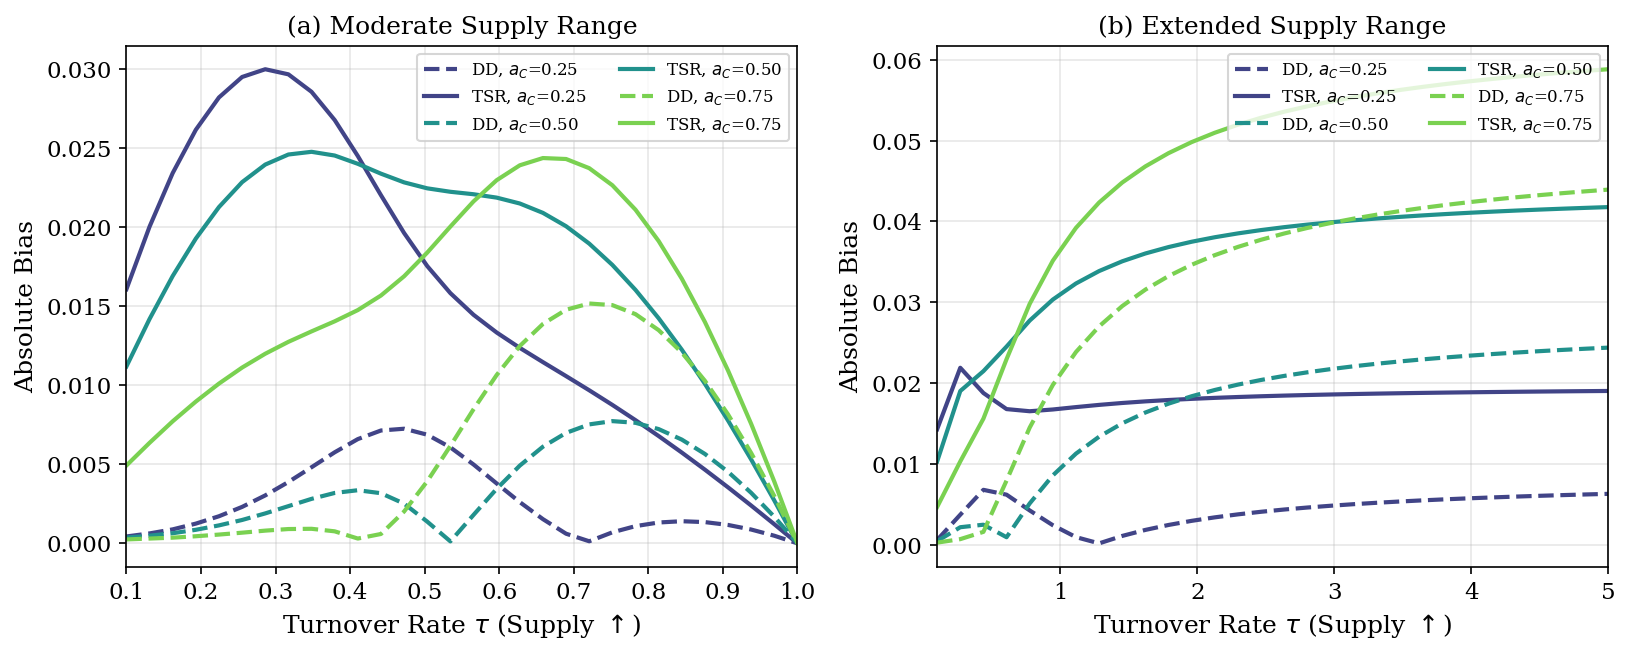

Saved supply_demand_sweep.pdf


In [55]:
# FIGURE 1: Supply-Demand Sweep

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left panel: Zoomed in (tau from 0.1 to 1.0)
grid_zoomed = np.linspace(0.1, 1.0, 30)
aC_values = [0.25, 0.5, 0.75]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(aC_values)))

for idx, aC in enumerate(aC_values):
    aL = 1 - aC
    bias_dd, bias_tsr = [], []

    for tau in grid_zoomed:
        taus = np.array([tau, tau])
        mu = 1.0 - tau

        Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(aC, aL, Ptilde_base, P_base,
                                                      epsilon_base, taus, mu, rho_base, phi_base)
        GTE_DD = Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL)

        bias_dd.append(np.abs(GTE_DD - GTE_true))
        bias_tsr.append(np.abs(GTE_TSR - GTE_true))

    ax1.plot(grid_zoomed, bias_dd, '--', color=colors[idx], linewidth=2,
            label=f'DD, $a_C$={aC:.2f}')
    ax1.plot(grid_zoomed, bias_tsr, '-', color=colors[idx], linewidth=2,
            label=f'TSR, $a_C$={aC:.2f}')

ax1.set_xlabel(r'Turnover Rate $\tau$ (Supply $\uparrow$)')
ax1.set_ylabel('Absolute Bias')
ax1.set_title('(a) Moderate Supply Range')
ax1.legend(loc='upper right', ncol=2, fontsize=8)
ax1.set_xlim(0.1, 1.0)
ax1.grid(True, alpha=0.3)

# Right panel: Extended range
grid_extended = np.linspace(0.1, 5.0, 30)

for idx, aC in enumerate(aC_values):
    aL = 1 - aC
    bias_dd, bias_tsr = [], []

    for tau in grid_extended:
        taus = np.array([tau, tau])
        mu = 0.5

        Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(aC, aL, Ptilde_base, P_base,
                                                      epsilon_base, taus, mu, rho_base, phi_base)
        GTE_DD = Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL)

        bias_dd.append(np.abs(GTE_DD - GTE_true))
        bias_tsr.append(np.abs(GTE_TSR - GTE_true))

    ax2.plot(grid_extended, bias_dd, '--', color=colors[idx], linewidth=2,
            label=f'DD, $a_C$={aC:.2f}')
    ax2.plot(grid_extended, bias_tsr, '-', color=colors[idx], linewidth=2,
            label=f'TSR, $a_C$={aC:.2f}')

ax2.set_xlabel(r'Turnover Rate $\tau$ (Supply $\uparrow$)')
ax2.set_ylabel('Absolute Bias')
ax2.set_title('(b) Extended Supply Range')
ax2.legend(loc='upper right', ncol=2, fontsize=8)
ax2.set_xlim(0.1, 5.0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('supply_demand_sweep.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved supply_demand_sweep.pdf")

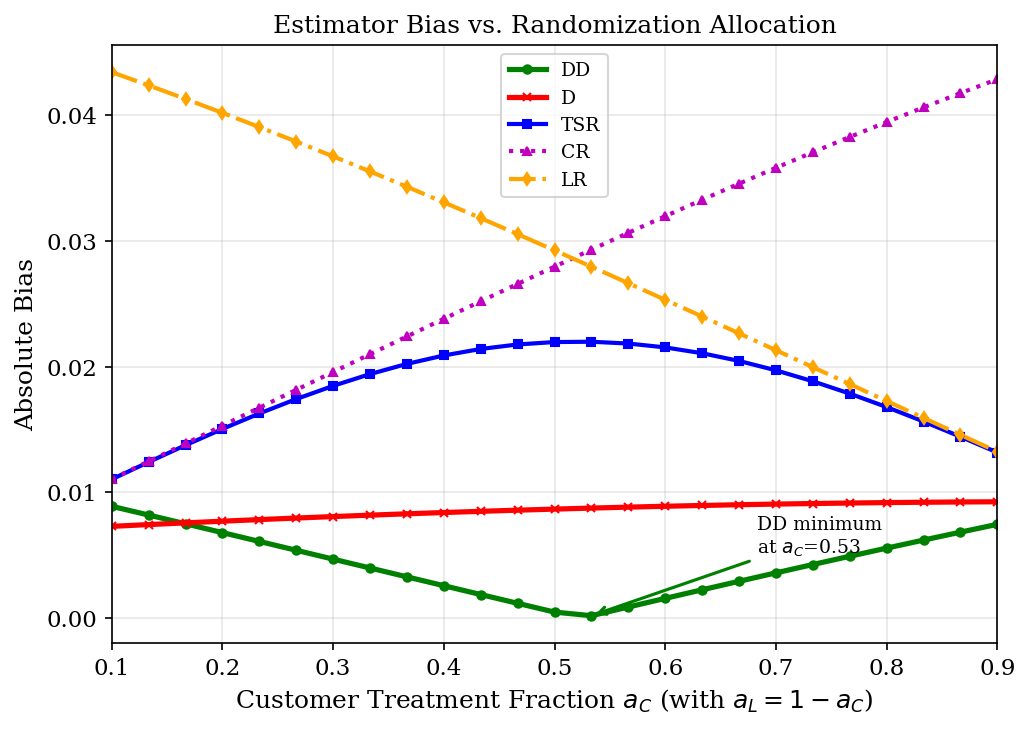

Saved randomization_sweep.pdf


In [56]:
# FIGURE 2: Randomization Sweep

fig, ax = plt.subplots(figsize=(7, 5))

taus = np.array([0.4, 0.6])
mu = 0.5

grid = np.linspace(0.1, 0.9, 25)
bias_dd, bias_d, bias_tsr, bias_cr, bias_lr = [], [], [], [], []

for aC in grid:
    aL = 1 - aC

    Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(aC, aL, Ptilde_base, P_base,
                                                  epsilon_base, taus, mu, rho_base, phi_base)
    GTE_DD = Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL)
    GTE_D = Q[1, 1] / (aL * aC) - Q[0, 0] / ((1 - aL) * (1 - aC))
    GTE_CR = Q[1, 1] / (aC * aL) - Q[0, 1] / ((1 - aC) * aL)
    GTE_LR = Q[1, 1] / (aC * aL) - Q[1, 0] / (aC * (1 - aL))

    bias_dd.append(np.abs(GTE_DD - GTE_true))
    bias_d.append(np.abs(GTE_D - GTE_true))
    bias_tsr.append(np.abs(GTE_TSR - GTE_true))
    bias_cr.append(np.abs(GTE_CR - GTE_true))
    bias_lr.append(np.abs(GTE_LR - GTE_true))

ax.plot(grid, bias_dd, 'g-', linewidth=2.5, label='DD', marker='o', markersize=4)
ax.plot(grid, bias_d, 'r-', linewidth=2.5, label='D', marker='x', markersize=4)
ax.plot(grid, bias_tsr, 'b-', linewidth=2, label='TSR', marker='s', markersize=4)
ax.plot(grid, bias_cr, 'm:', linewidth=2, label='CR', marker='^', markersize=4)
ax.plot(grid, bias_lr, color='orange', linestyle='-.', linewidth=2, label='LR', marker='d', markersize=4)

ax.set_xlabel(r'Customer Treatment Fraction $a_C$ (with $a_L = 1 - a_C$)')
ax.set_ylabel('Absolute Bias')
ax.set_title('Estimator Bias vs. Randomization Allocation')
ax.legend(loc='upper center')
ax.set_xlim(0.1, 0.9)
ax.grid(True, alpha=0.3)

# Annotate DD minimum
min_idx = np.argmin(bias_dd)
ax.annotate(f'DD minimum\nat $a_C$={grid[min_idx]:.2f}',
            xy=(grid[min_idx], bias_dd[min_idx]),
            xytext=(grid[min_idx]+0.15, bias_dd[min_idx]+0.005),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

plt.tight_layout()
plt.savefig('randomization_sweep.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved randomization_sweep.pdf")

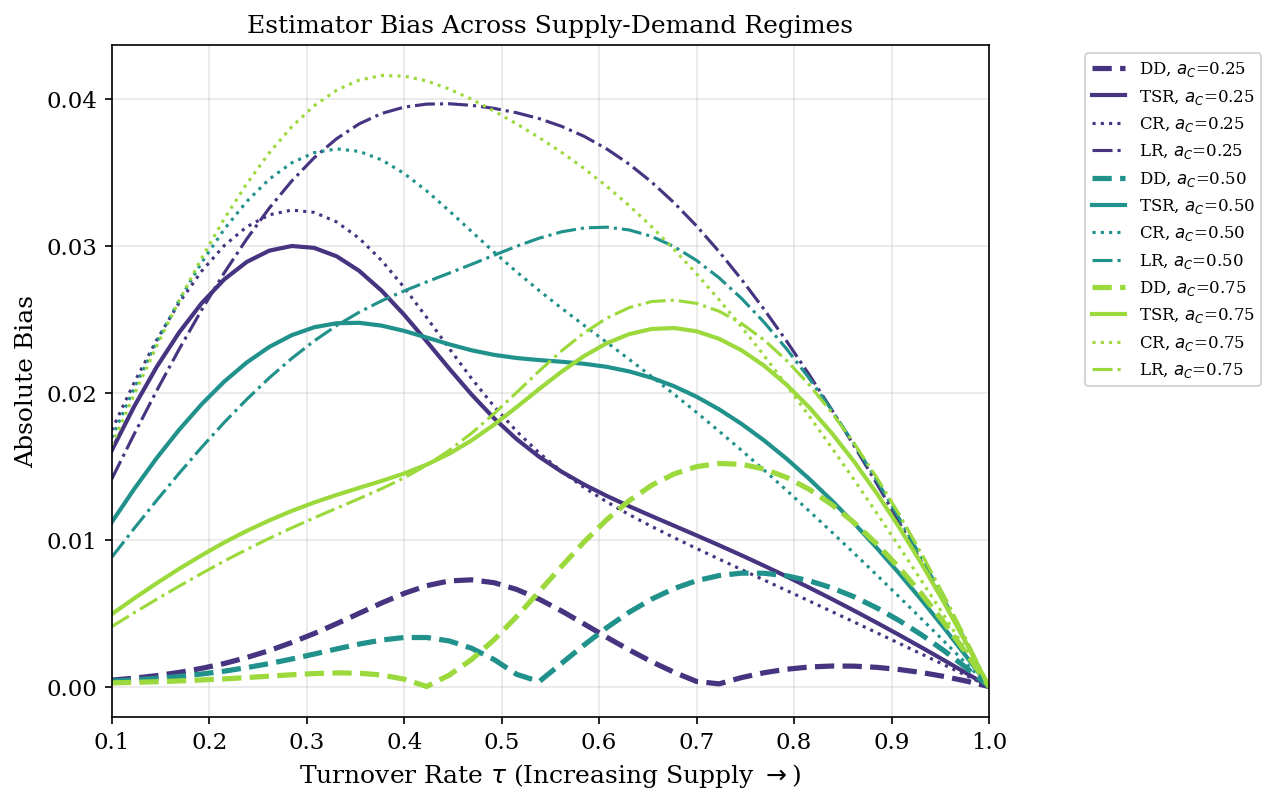

Saved four_estimator_comparison.pdf


In [57]:
# FIGURE 3: Four Estimator Comparison

fig, ax = plt.subplots(figsize=(9, 5.5))

grid = np.linspace(0.1, 1.0, 40)
aC_values = [0.25, 0.5, 0.75]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(aC_values)))

for idx, aC in enumerate(aC_values):
    aL = 1 - aC
    bias_dd, bias_tsr, bias_cr, bias_lr = [], [], [], []

    for tau in grid:
        taus = np.array([tau, tau])
        mu = 1.0 - tau

        Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(aC, aL, Ptilde_base, P_base,
                                                      epsilon_base, taus, mu, rho_base, phi_base)
        GTE_DD = Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL)
        GTE_CR = Q[1, 1] / (aC * aL) - Q[0, 1] / ((1 - aC) * aL)
        GTE_LR = Q[1, 1] / (aC * aL) - Q[1, 0] / (aC * (1 - aL))

        bias_dd.append(np.abs(GTE_DD - GTE_true))
        bias_tsr.append(np.abs(GTE_TSR - GTE_true))
        bias_cr.append(np.abs(GTE_CR - GTE_true))
        bias_lr.append(np.abs(GTE_LR - GTE_true))

    ax.plot(grid, bias_dd, '--', color=colors[idx], linewidth=2.5,
            label=f'DD, $a_C$={aC:.2f}')
    ax.plot(grid, bias_tsr, '-', color=colors[idx], linewidth=2,
            label=f'TSR, $a_C$={aC:.2f}')
    ax.plot(grid, bias_cr, ':', color=colors[idx], linewidth=1.5,
            label=f'CR, $a_C$={aC:.2f}')
    ax.plot(grid, bias_lr, '-.', color=colors[idx], linewidth=1.5,
            label=f'LR, $a_C$={aC:.2f}')

ax.set_xlabel(r'Turnover Rate $\tau$ (Increasing Supply $\rightarrow$)')
ax.set_ylabel('Absolute Bias')
ax.set_title('Estimator Bias Across Supply-Demand Regimes')
ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1), ncol=1, fontsize=8)
ax.set_xlim(0.1, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('four_estimator_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved four_estimator_comparison.pdf")

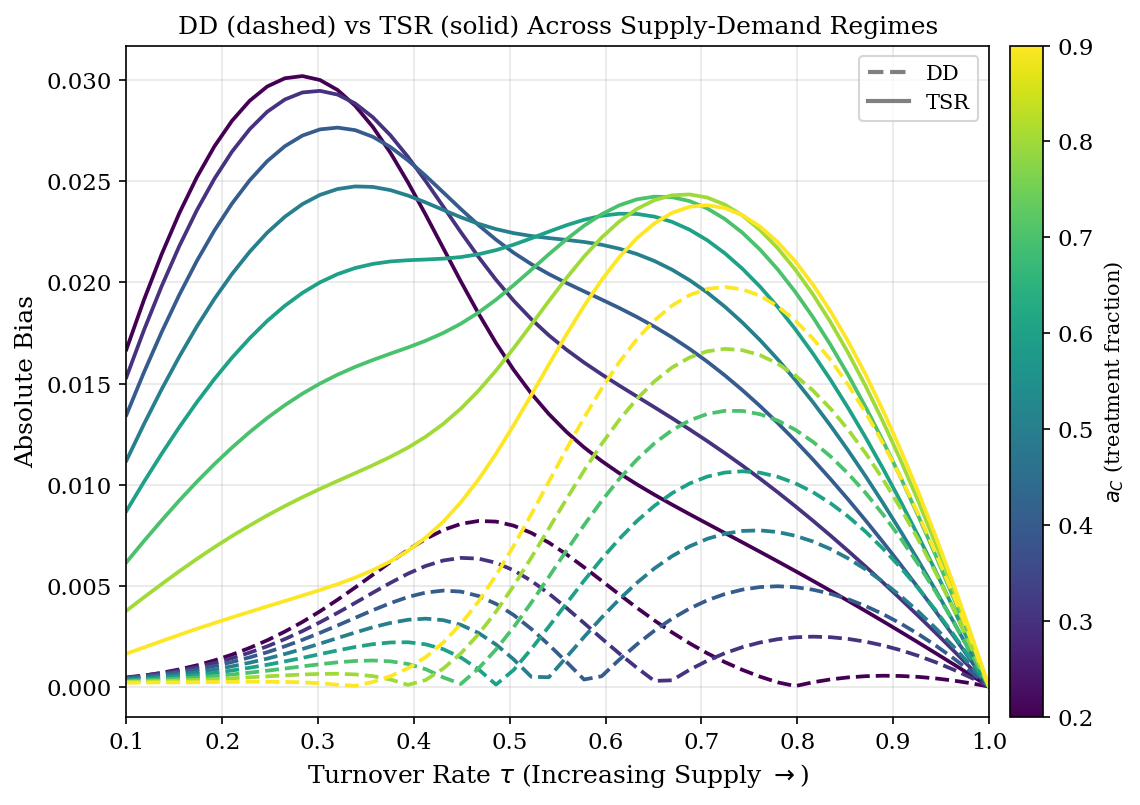

Saved dd_vs_tsr_focused.pdf


In [58]:
# FIGURE 4: DD vs TSR Focused (with colorbar)

fig, ax = plt.subplots(figsize=(8, 5.5))

grid = np.linspace(0.1, 1.0, 50)
aC_values = np.linspace(0.2, 0.9, 8)
colors = plt.cm.viridis(np.linspace(0, 1, len(aC_values)))

for idx, aC in enumerate(aC_values):
    aL = 1 - aC
    bias_dd, bias_tsr = [], []

    for tau in grid:
        taus = np.array([tau, tau])
        mu = 1.0 - tau

        Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(aC, aL, Ptilde_base, P_base,
                                                      epsilon_base, taus, mu, rho_base, phi_base)
        GTE_DD = Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL)

        bias_dd.append(np.abs(GTE_DD - GTE_true))
        bias_tsr.append(np.abs(GTE_TSR - GTE_true))

    ax.plot(grid, bias_dd, '--', color=colors[idx], linewidth=1.8,
            label=f'DD, $a_C$={aC:.2f}')
    ax.plot(grid, bias_tsr, '-', color=colors[idx], linewidth=1.8,
            label=f'TSR, $a_C$={aC:.2f}')

ax.set_xlabel(r'Turnover Rate $\tau$ (Increasing Supply $\rightarrow$)', fontsize=12)
ax.set_ylabel('Absolute Bias', fontsize=12)
ax.set_title('DD (dashed) vs TSR (solid) Across Supply-Demand Regimes', fontsize=12)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='DD'),
    Line2D([0], [0], color='gray', linestyle='-', linewidth=2, label='TSR'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0.2, vmax=0.9))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'$a_C$ (treatment fraction)', fontsize=10)

ax.set_xlim(0.1, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dd_vs_tsr_focused.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved dd_vs_tsr_focused.pdf")

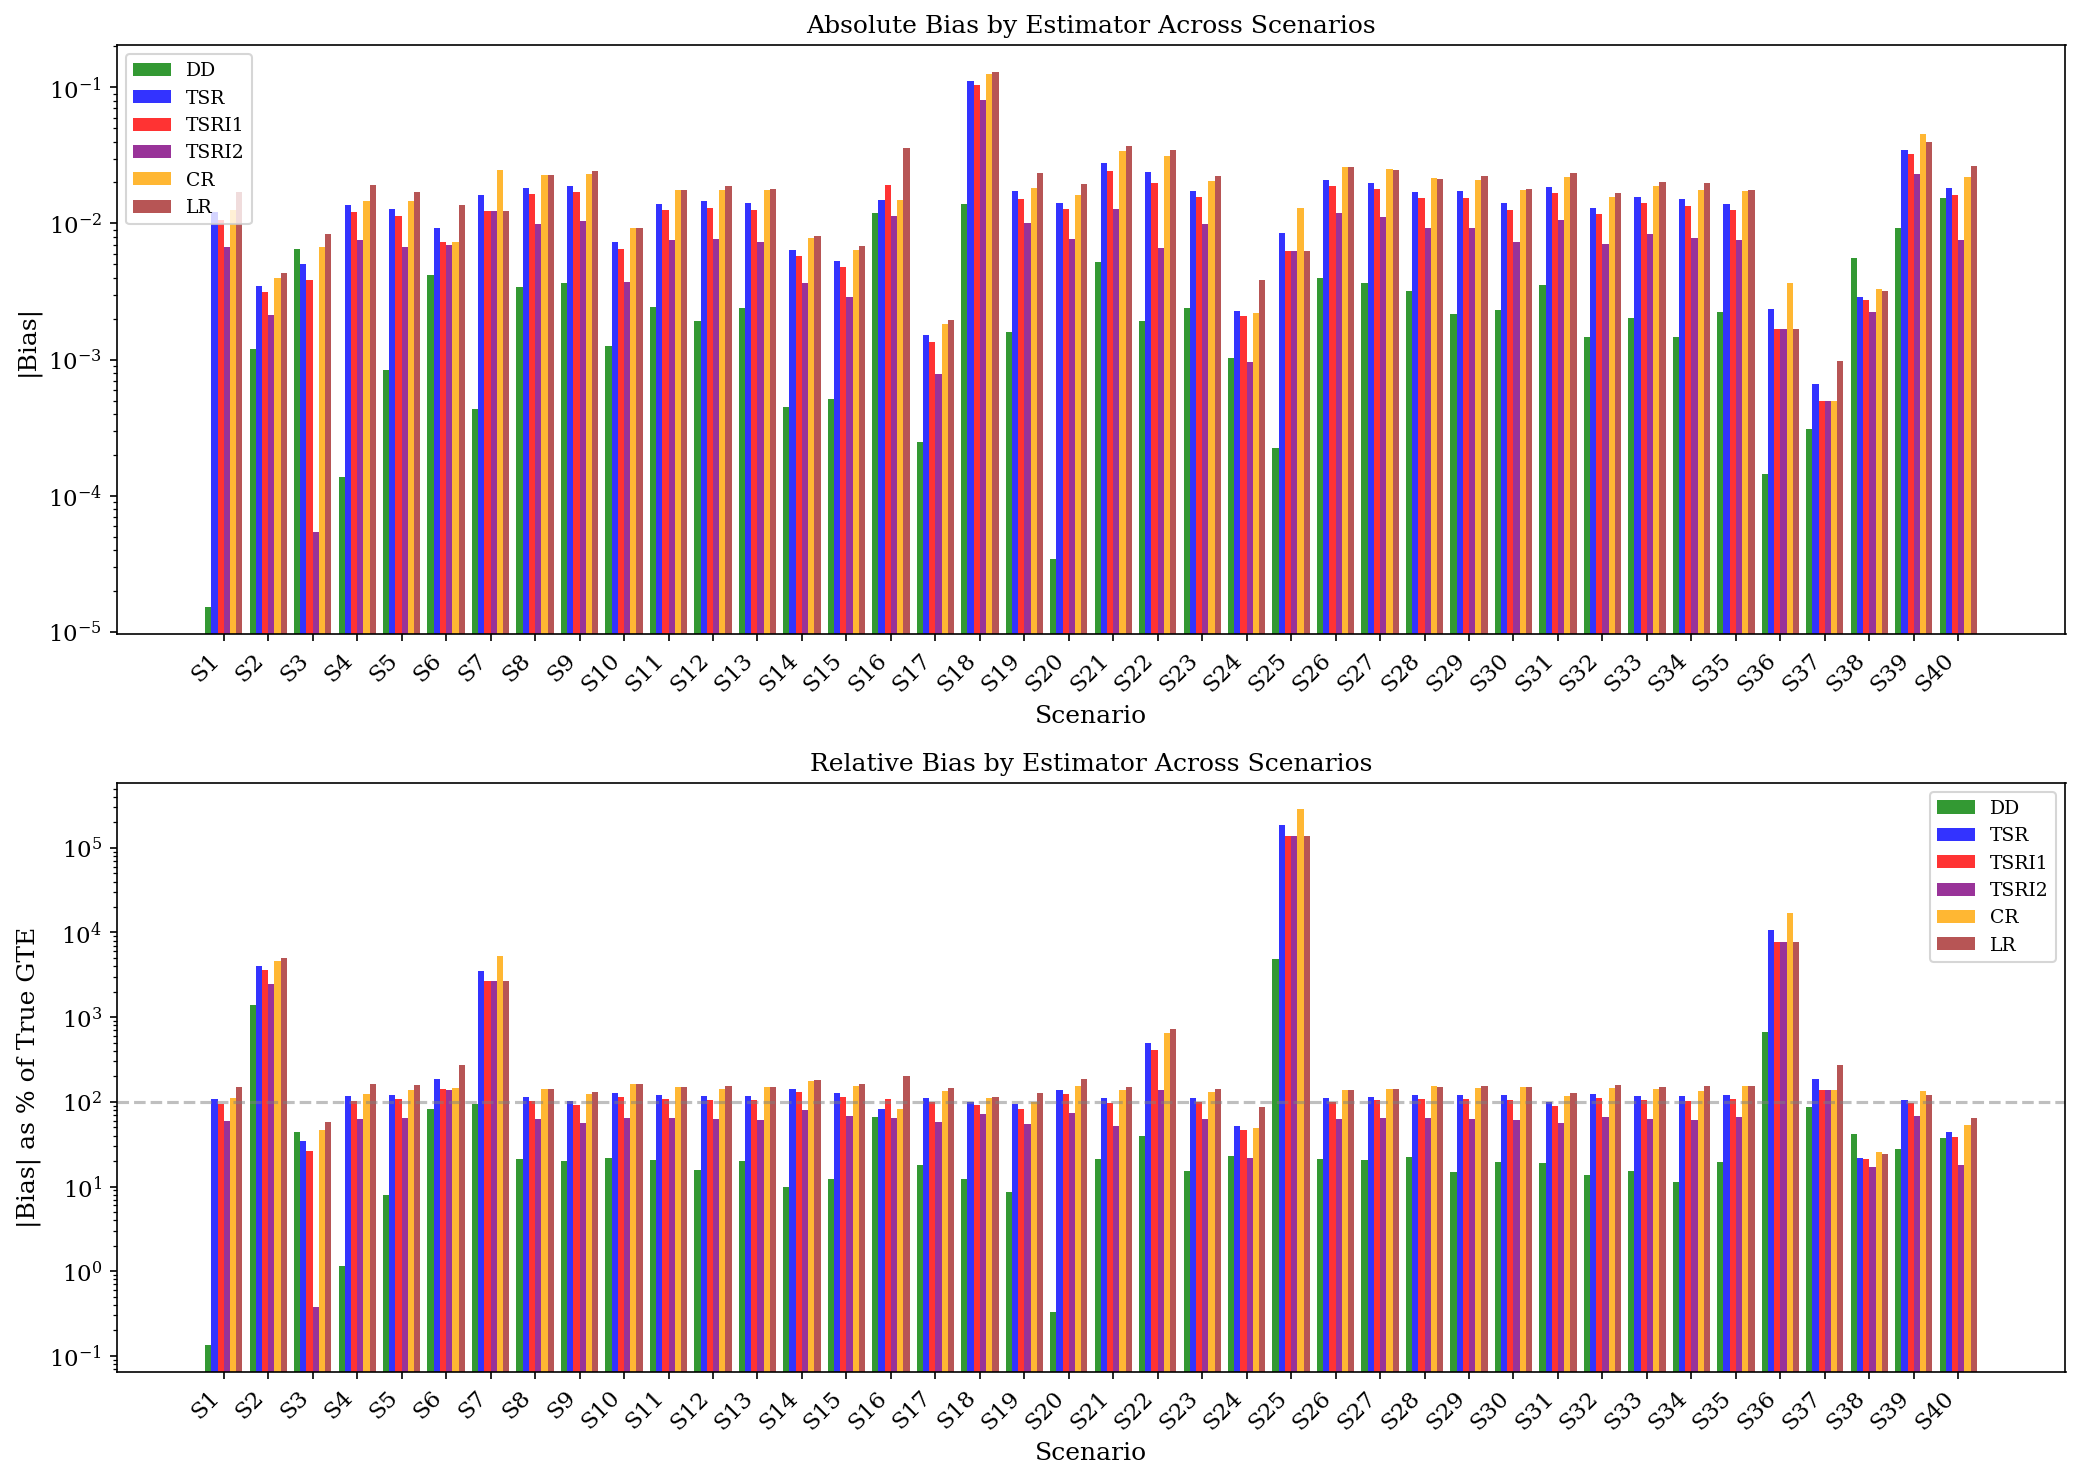

Saved bias_comparison.pdf


In [59]:
# FIGURE 5: Bar chart of absolute and relative bias across scenarios

# Filter valid scenarios
valid_idx = df_valid['scenario_num'].values - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Absolute biases
biases_DD = [abs(all_results[i]['bias_DD']) for i in valid_idx]
biases_TSR = [abs(all_results[i]['bias_TSR']) for i in valid_idx]
biases_CR = [abs(all_results[i]['bias_CR']) for i in valid_idx]
biases_LR = [abs(all_results[i]['bias_LR']) for i in valid_idx]
biases_TSRI1 = [abs(all_results[i]['bias_TSRI1']) for i in valid_idx]
biases_TSRI2 = [abs(all_results[i]['bias_TSRI2']) for i in valid_idx]

x = np.arange(len(valid_idx))
width = 0.14

ax1 = axes[0]
ax1.bar(x - 2.5*width, biases_DD, width, label='DD', color='green', alpha=0.8)
ax1.bar(x - 1.5*width, biases_TSR, width, label='TSR', color='blue', alpha=0.8)
ax1.bar(x - 0.5*width, biases_TSRI1, width, label='TSRI1', color='red', alpha=0.8)
ax1.bar(x + 0.5*width, biases_TSRI2, width, label='TSRI2', color='purple', alpha=0.8)
ax1.bar(x + 1.5*width, biases_CR, width, label='CR', color='orange', alpha=0.8)
ax1.bar(x + 2.5*width, biases_LR, width, label='LR', color='brown', alpha=0.8)

ax1.set_xlabel('Scenario')
ax1.set_ylabel('|Bias|')
ax1.set_title('Absolute Bias by Estimator Across Scenarios')
ax1.set_xticks(x)
ax1.set_xticklabels([f'S{i+1}' for i in valid_idx], rotation=45, ha='right')
ax1.legend()
ax1.set_yscale('log')

# Relative biases
ax2 = axes[1]
rel_biases_DD = [100 * abs(all_results[i]['bias_DD']) / abs(all_results[i]['GTE_true']) for i in valid_idx]
rel_biases_TSR = [100 * abs(all_results[i]['bias_TSR']) / abs(all_results[i]['GTE_true']) for i in valid_idx]
rel_biases_CR = [100 * abs(all_results[i]['bias_CR']) / abs(all_results[i]['GTE_true']) for i in valid_idx]
rel_biases_LR = [100 * abs(all_results[i]['bias_LR']) / abs(all_results[i]['GTE_true']) for i in valid_idx]
# Corrected keys from 'bias_TSR1'/'bias_TSR2' to 'bias_TSRI1'/'bias_TSRI2'
rel_biases_TSRI1 = [100 * abs(all_results[i]['bias_TSRI1']) / abs(all_results[i]['GTE_true']) for i in valid_idx]
rel_biases_TSRI2 = [100 * abs(all_results[i]['bias_TSRI2']) / abs(all_results[i]['GTE_true']) for i in valid_idx]


ax2.bar(x - 2.5*width, rel_biases_DD, width, label='DD', color='green', alpha=0.8)
ax2.bar(x - 1.5*width, rel_biases_TSR, width, label='TSR', color='blue', alpha=0.8)
ax2.bar(x - 0.5*width, rel_biases_TSRI1, width, label='TSRI1', color='red', alpha=0.8)
ax2.bar(x + 0.5*width, rel_biases_TSRI2, width, label='TSRI2', color='purple', alpha=0.8)
ax2.bar(x + 1.5*width, rel_biases_CR, width, label='CR', color='orange', alpha=0.8)
ax2.bar(x + 2.5*width, rel_biases_LR, width, label='LR', color='brown', alpha=0.8)

ax2.set_xlabel('Scenario')
ax2.set_ylabel('|Bias| as % of True GTE')
ax2.set_title('Relative Bias by Estimator Across Scenarios')
ax2.set_xticks(x)
ax2.set_xticklabels([f'S{i+1}' for i in valid_idx], rotation=45, ha='right')
ax2.legend()
ax2.set_yscale('log')
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('bias_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved bias_comparison.pdf")

## 6. Export Results to CSV

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
# Export all results to CSV for further analysis
export_df = df[['scenario_num', 'name', 'n_customers', 'n_listings', 'mu', 'aC', 'aL',
                'GTE_true', 'GTE_DD', 'GTE_TSR', 'GTE_CR', 'GTE_LR',
                'bias_DD', 'bias_TSR', 'bias_CR', 'bias_LR',
                'rel_bias_DD', 'rel_bias_TSR', 'rel_bias_CR', 'rel_bias_LR', 'winner']]

export_df.to_csv('/content/drive/MyDrive/experiment_results.csv', index=False)
print("Exported results to experiment_results.csv")
print(f"\nDataFrame shape: {export_df.shape}")
export_df.head(10)

Exported results to experiment_results.csv

DataFrame shape: (40, 21)


,scenario_num,name,n_customers,n_listings,mu,aC,aL,GTE_true,GTE_DD,GTE_TSR,...,GTE_LR,bias_DD,bias_TSR,bias_CR,bias_LR,rel_bias_DD,rel_bias_TSR,rel_bias_CR,rel_bias_LR,winner
0,1,Uniform improvement (+0.1 to all P_ij),3,2,0.30,0.5,0.5,0.011261,0.011276,0.023385,...,0.028192,0.000015,0.012124,0.012541,0.016932,0.134399,107.671160,111.372341,150.365068,DD
1,2,"Single cell change (P[0,0]: 0.1 -> 0.5)",3,2,0.30,0.5,0.5,0.000086,0.001287,0.003545,...,0.004394,0.001201,0.003459,0.003944,0.004308,1389.566966,4002.182814,4563.707256,4985.045343,DD
2,3,"Treatment helps listing type 1, hurts type 2",3,2,0.40,0.5,0.5,-0.014500,-0.008048,-0.019499,...,-0.022907,0.006452,-0.004999,-0.006700,-0.008407,44.494727,-34.475390,-46.207811,-57.982628,TSRI2
3,4,Small varying effect by listing type (+0.05 vs...,3,2,0.30,0.5,0.5,0.011895,0.012031,0.025661,...,0.031015,0.000136,0.013766,0.014566,0.019121,1.147065,115.735729,122.456529,160.751961,DD
4,5,Small varying effect by customer type,3,2,0.35,0.5,0.5,0.010582,0.009736,0.023283,...,0.027485,-0.000846,0.012701,0.014607,0.016903,-7.991886,120.028177,138.034152,159.733522,DD
5,6,"High supply, low demand (taus=2.0, mu=0.1)",3,2,0.10,0.5,0.5,0.005080,0.009244,0.014419,...,0.018824,0.004164,0.009340,0.007306,0.013745,81.967256,183.857776,143.819408,270.575342,DD
6,7,"Low supply, high demand (taus=0.1, mu=2.0)",3,2,2.00,0.5,0.5,0.000464,0.000027,0.016706,...,0.012859,-0.000436,0.016243,0.024569,0.012395,-94.096950,3504.381426,5300.669089,2674.276066,DD
7,8,"Many customer types (10 customers, 2 listings)",10,2,0.50,0.5,0.5,0.016002,0.012600,0.034104,...,0.038773,-0.003402,0.018102,0.022554,0.022770,-21.261081,113.121370,140.943136,142.294311,DD
8,9,"Many listing types (2 customers, 10 listings)",2,10,0.50,0.5,0.5,0.018310,0.014641,0.037232,...,0.042474,-0.003670,0.018921,0.022897,0.024163,-20.041237,103.336644,125.046203,131.963804,DD
9,10,Sparse market (specialized customer-listing ma...,3,3,0.40,0.5,0.5,0.005727,0.004477,0.013001,...,0.014928,-0.001250,0.007274,0.009297,0.009201,-21.831250,127.003653,162.336731,160.648417,DD


In [62]:
export_df

,scenario_num,name,n_customers,n_listings,mu,aC,aL,GTE_true,GTE_DD,GTE_TSR,...,GTE_LR,bias_DD,bias_TSR,bias_CR,bias_LR,rel_bias_DD,rel_bias_TSR,rel_bias_CR,rel_bias_LR,winner
0,1,Uniform improvement (+0.1 to all P_ij),3,2,0.30,0.5,0.5,0.011261,0.011276,0.023385,...,0.028192,0.000015,0.012124,0.012541,0.016932,0.134399,107.671160,111.372341,150.365068,DD
1,2,"Single cell change (P[0,0]: 0.1 -> 0.5)",3,2,0.30,0.5,0.5,0.000086,0.001287,0.003545,...,0.004394,0.001201,0.003459,0.003944,0.004308,1389.566966,4002.182814,4563.707256,4985.045343,DD
2,3,"Treatment helps listing type 1, hurts type 2",3,2,0.40,0.5,0.5,-0.014500,-0.008048,-0.019499,...,-0.022907,0.006452,-0.004999,-0.006700,-0.008407,44.494727,-34.475390,-46.207811,-57.982628,TSRI2
3,4,Small varying effect by listing type (+0.05 vs...,3,2,0.30,0.5,0.5,0.011895,0.012031,0.025661,...,0.031015,0.000136,0.013766,0.014566,0.019121,1.147065,115.735729,122.456529,160.751961,DD
4,5,Small varying effect by customer type,3,2,0.35,0.5,0.5,0.010582,0.009736,0.023283,...,0.027485,-0.000846,0.012701,0.014607,0.016903,-7.991886,120.028177,138.034152,159.733522,DD
5,6,"High supply, low demand (taus=2.0, mu=0.1)",3,2,0.10,0.5,0.5,0.005080,0.009244,0.014419,...,0.018824,0.004164,0.009340,0.007306,0.013745,81.967256,183.857776,143.819408,270.575342,DD
6,7,"Low supply, high demand (taus=0.1, mu=2.0)",3,2,2.00,0.5,0.5,0.000464,0.000027,0.016706,...,0.012859,-0.000436,0.016243,0.024569,0.012395,-94.096950,3504.381426,5300.669089,2674.276066,DD
7,8,"Many customer types (10 customers, 2 listings)",10,2,0.50,0.5,0.5,0.016002,0.012600,0.034104,...,0.038773,-0.003402,0.018102,0.022554,0.022770,-21.261081,113.121370,140.943136,142.294311,DD
8,9,"Many listing types (2 customers, 10 listings)",2,10,0.50,0.5,0.5,0.018310,0.014641,0.037232,...,0.042474,-0.003670,0.018921,0.022897,0.024163,-20.041237,103.336644,125.046203,131.963804,DD
9,10,Sparse market (specialized customer-listing ma...,3,3,0.40,0.5,0.5,0.005727,0.004477,0.013001,...,0.014928,-0.001250,0.007274,0.009297,0.009201,-21.831250,127.003653,162.336731,160.648417,DD


In [63]:
def compute_DD(Q, aL):
    if np.isclose(aL, 1.0):
        return Q[1, 1] + Q[0, 1]

    return Q[1, 1] / aL - Q[1, 0] / (1 - aL) + Q[0, 1] / aL - Q[0, 0] / (1 - aL)

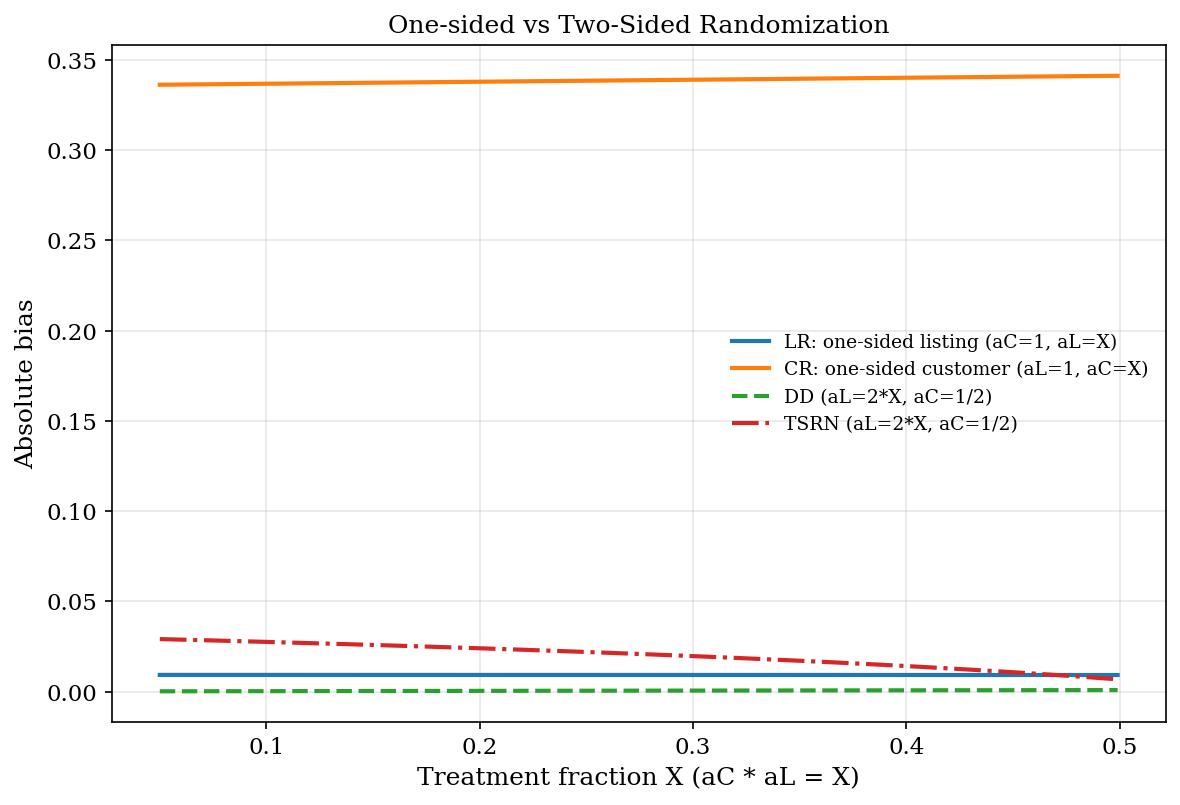

In [64]:
# FIGURE: One-sided vs Symmetric Randomization Comparison

fig, ax = plt.subplots(figsize=(8, 5.5))

grid = np.linspace(0.05, 0.499, 40)

bias_listing = []
bias_customer = []
bias_dd_sym = []
bias_tsr_sym = []

taus = np.array([0.4, 0.6])
mu = 0.5

for X in grid:
    # One-sided listing randomization (aC=1, aL=X)
    aL = X
    Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(
        aC=1.0, aL=aL,
        taus=taus, mu=mu,
        P=P_base, Ptilde=Ptilde_base,
        epsilon=epsilon_base, rho=rho_base, phi=phi_base
    )

    DD = compute_DD(Q, aL)
    bias_listing.append(abs(DD - GTE_true))

    # One-sided customer randomization (aL=1, aC=X)
    aL = 1.0
    Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(
        aC=X, aL=aL,
        taus=taus, mu=mu,
        P=P_base, Ptilde=Ptilde_base,
        epsilon=epsilon_base, rho=rho_base, phi=phi_base
    )

    DD = compute_DD(Q, aL)
    bias_customer.append(abs(DD - GTE_true))

    # aC=1/2, aL = 2X, so aC*aL=X
    aL = 2 * X

    Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(
        aC=0.5, aL=2*X,
        taus=taus, mu=mu,
        P=P_base, Ptilde=Ptilde_base,
        epsilon=epsilon_base, rho=rho_base, phi=phi_base
    )

    DD = compute_DD(Q, aL)
    bias_dd_sym.append(abs(DD - GTE_true))
    bias_tsr_sym.append(abs(GTE_TSR - GTE_true))

# Plot
ax.plot(grid, bias_listing, label='LR: one-sided listing (aC=1, aL=X)', linewidth=2)
ax.plot(grid, bias_customer, label='CR: one-sided customer (aL=1, aC=X)', linewidth=2)
ax.plot(grid, bias_dd_sym, label='DD (aL=2*X, aC=1/2)', linestyle='--', linewidth=2)
ax.plot(grid, bias_tsr_sym, label='TSRN (aL=2*X, aC=1/2)', linestyle='-.', linewidth=2)

ax.set_xlabel('Treatment fraction X (aC * aL = X)')
ax.set_ylabel('Absolute bias')
ax.set_title('One-sided vs Two-Sided Randomization')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


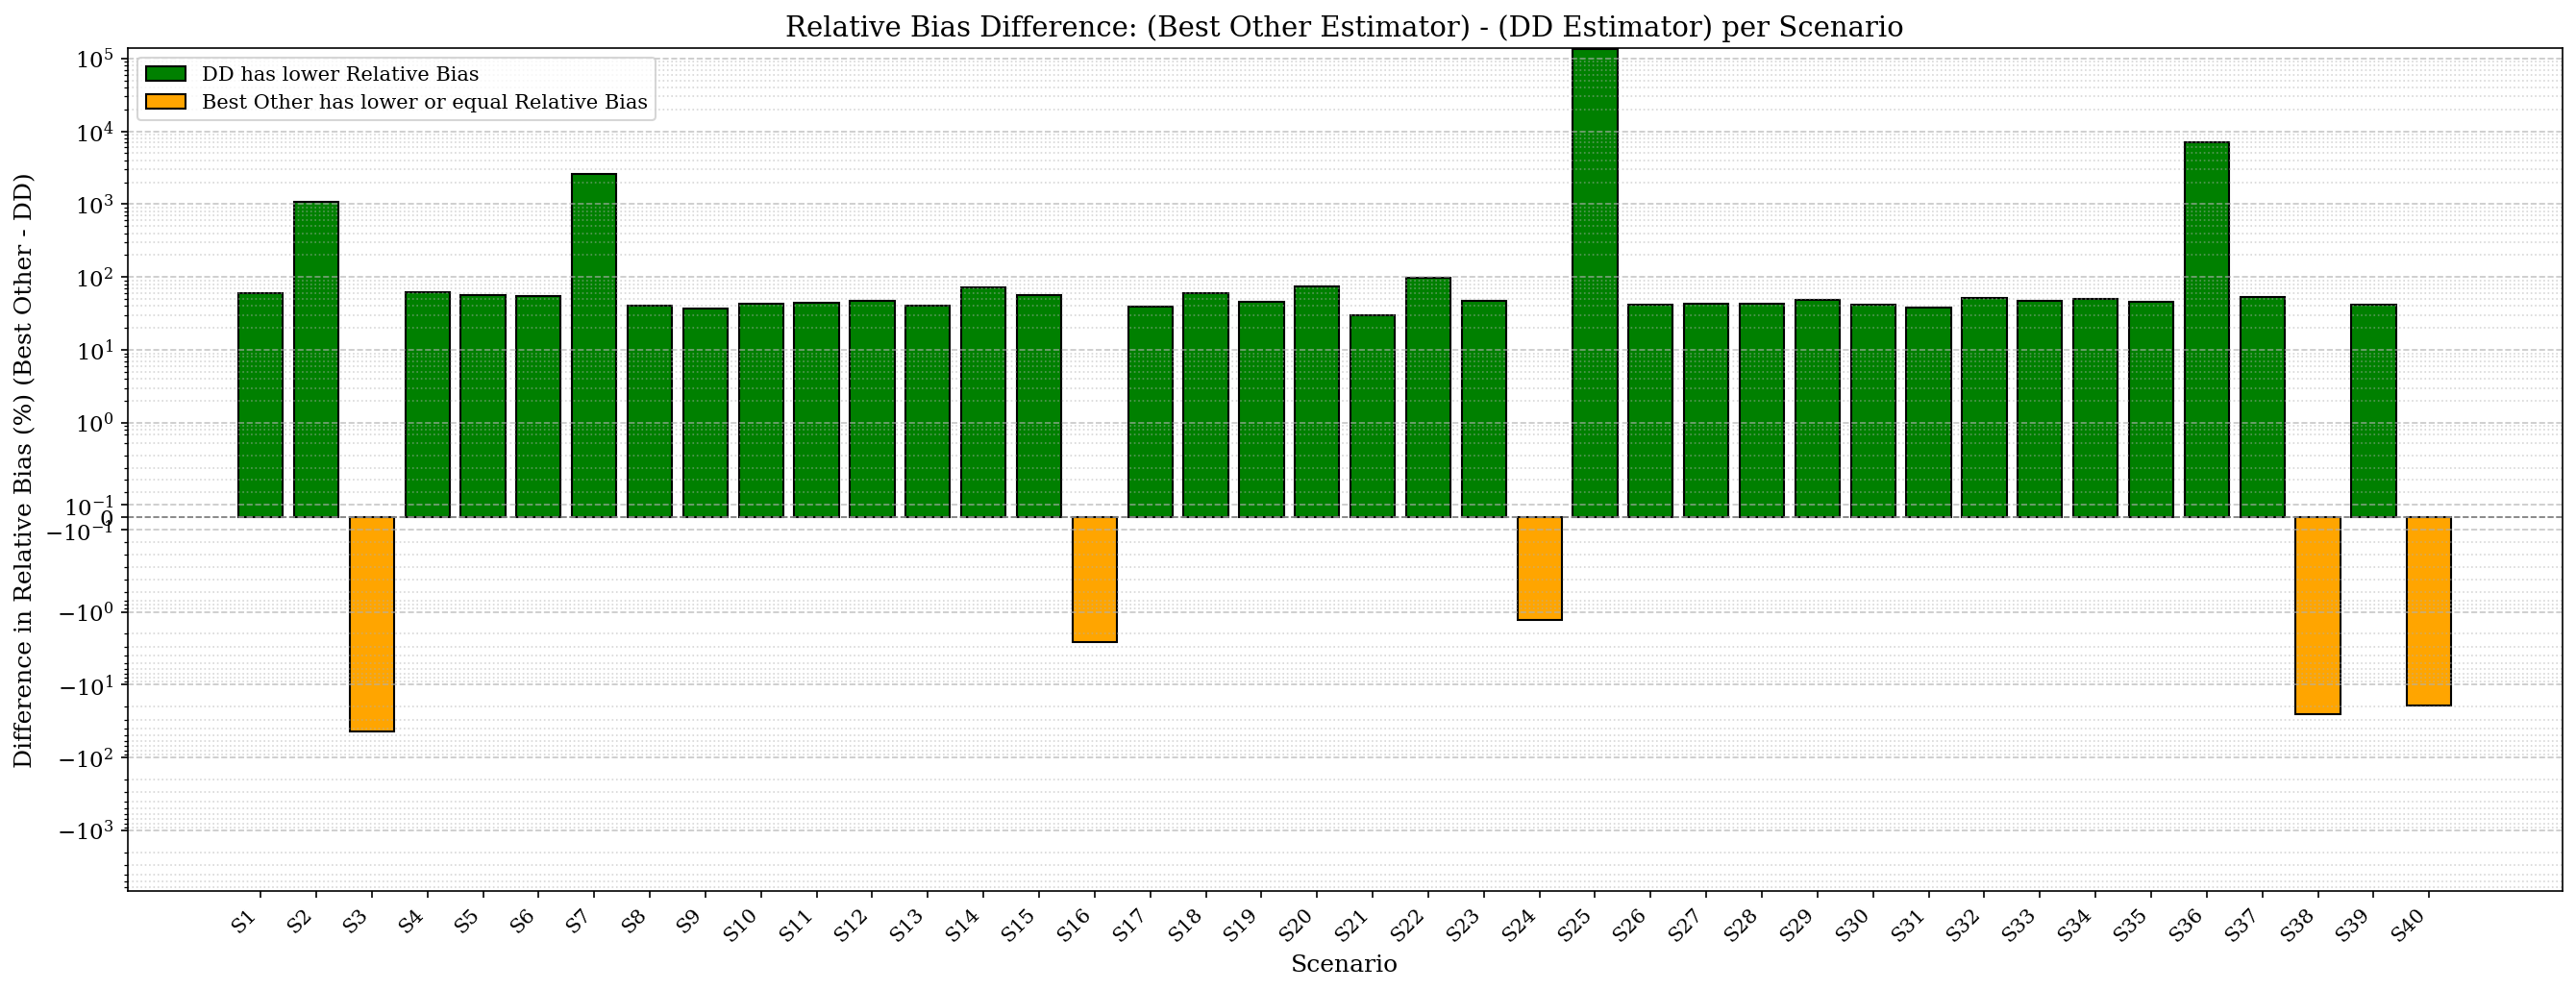

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

if 'df_valid' not in locals():
    print("df_valid not found. Please run previous cells first.")
else:
    df_plot = df_valid.copy()
    if 'Scenario' not in df_plot.columns:
        df_plot['Scenario'] = [f'S{i+1}' for i in range(len(df_plot))]

    methods_other = ['TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']

    bias_differences = []
    difference_colors = []
    scenario_labels = df_plot['Scenario'].tolist()

    for _, row in df_plot.iterrows():
        dd_rel_bias = abs(row['rel_bias_DD'])

        min_other_rel_bias = np.inf
        for m in methods_other:
            current_rel_bias = abs(row[f'rel_bias_{m}'])
            if current_rel_bias < min_other_rel_bias:
                min_other_rel_bias = current_rel_bias

        # Calculate the difference: (Best Other Bias) - (DD Bias)
        # A positive difference means DD has smaller bias (DD wins)
        # A negative difference means Best Other has smaller bias (DD loses)
        diff = min_other_rel_bias - dd_rel_bias
        bias_differences.append(diff)

        # Assign colors based on the difference
        if diff > 0: # DD is better (smaller bias)
            difference_colors.append('green')
        else: # Best Other is better or equal (smaller bias or equal)
            difference_colors.append('orange')

    x = np.arange(len(scenario_labels))
    width = 0.8 # Width of the bars

    fig, ax = plt.subplots(figsize=(18, 7))

    ax.bar(x, bias_differences, width, color=difference_colors, edgecolor='black')

    ax.set_xlabel('Scenario', fontsize=12)
    ax.set_ylabel('Difference in Relative Bias (%) (Best Other - DD)', fontsize=12)

    ax.set_title('Relative Bias Difference: (Best Other Estimator) - (DD Estimator) per Scenario', fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels(scenario_labels, rotation=45, ha='right', fontsize=10)

    abs_non_zero_diffs = [abs(d) for d in bias_differences if d != 0]
    linthresh = 0.1 if not abs_non_zero_diffs else min(abs_non_zero_diffs) * 0.5

    # Set the y-axis to a symmetrical logarithmic scale
    ax.set_yscale('symlog', linthresh=linthresh, subs=[2, 3, 4, 5, 6, 7, 8, 9])

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    ax.grid(axis='y', which='major', linestyle='--', alpha=0.7)
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.5)

    legend_handles = [
        Patch(facecolor='green', edgecolor='black', label='DD has lower Relative Bias'),
        Patch(facecolor='orange', edgecolor='black', label='Best Other has lower or equal Relative Bias')
    ]
    ax.legend(handles=legend_handles, fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.show()


<!--
```python
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch

# Base parameters for figure generation
P_base = np.array([[0.1, 0.9], [0.9, 0.1], [0.2, 0.8]])
Ptilde_base = np.array([[0.5, 0.95], [0.95, 0.5], [0.6, 0.9]])
epsilon_base = np.array([0.2, 0.2, 0.2])
rho_base = np.array([0.3, 0.7])
phi_base = np.array([0.3, 0.3, 0.4])

# =============================================================================
# GENERATE HEATMAP DATA for DD vs TSR bias difference
# =============================================================================

print("Generating heatmap data for DD vs. TSR bias difference...")

# Grid for tau and aC
# tau_values_zoomed = np.linspace(0.1, 1.0, 25) # Original had 25, paper has 30
tau_values_zoomed = np.linspace(0.1, 1.0, 30)
# tau_values_extended = np.linspace(0.1, 5.0, 25) # Original had 25, paper has 30
tau_values_extended = np.linspace(0.1, 5.0, 30)
# aC_values = np.linspace(0.15, 0.85, 20) # Original had 20, paper has 30
aC_values = np.linspace(0.15, 0.85, 30)


# Storage for both panels
data_zoomed_bias_diff = []
data_extended_bias_diff = []

# Panel (a): Moderate range with mu = 1 - tau
print("  Computing moderate range (mu = 1 - tau)...")
for aC in aC_values:
    aL = 1 - aC
    row_bias_diff = []

    for tau in tau_values_zoomed:
        taus = np.array([tau, tau])
        mu = 1.0 - tau

        Q, Qc, Qt, GTE_TSR_val, GTE_true = bias_analysis(
            aC, aL, Ptilde_base, P_base, epsilon_base, taus, mu, rho_base, phi_base
        )
        # Note: GTE_DD calculation here is from the `compute_all_estimators` function,
        # not the simpler version used in some other plots.
        # Ensure consistency with the definition of GTE_DD used in the rest of the notebook.
        # In `compute_all_estimators`, it's: GTE_DD = (Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL))
        # The `bias_analysis` function used here only returns GTE_TSR, so we need to compute GTE_DD from Q.
        GTE_DD_val = (Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL))

        bias_dd = np.abs(GTE_DD_val - GTE_true)
        bias_tsr = np.abs(GTE_TSR_val - GTE_true)

        # Difference in absolute bias: positive means DD is worse, negative means DD is better
        # We want color to indicate who is better: green for DD, red for TSR
        # So, we can store 1 if DD is better, -1 if TSR is better, 0 if equal
        if bias_dd < bias_tsr:
            row_bias_diff.append(-1)  # DD has lower bias (DD better)
        elif bias_tsr < bias_dd:
            row_bias_diff.append(1)   # TSR has lower bias (TSR better)
        else:
            row_bias_diff.append(0)   # Equal (should be rare with floats)

    data_zoomed_bias_diff.append(row_bias_diff)

# Panel (b): Extended range with mu = 0.5 fixed
print("  Computing extended range (mu = 0.5 fixed)...")
for aC in aC_values:
    aL = 1 - aC
    row_bias_diff = []

    for tau in tau_values_extended:
        taus = np.array([tau, tau])
        mu = 0.5  # Fixed

        Q, Qc, Qt, GTE_TSR_val, GTE_true = bias_analysis(
            aC, aL, Ptilde_base, P_base, epsilon_base, taus, mu, rho_base, phi_base
        )
        GTE_DD_val = (Q[1, 1] / aL + Q[0, 1] / aL - Q[1, 0] / (1 - aL) - Q[0, 0] / (1 - aL))

        bias_dd = np.abs(GTE_DD_val - GTE_true)
        bias_tsr = np.abs(GTE_TSR_val - GTE_true)

        if bias_dd < bias_tsr:
            row_bias_diff.append(-1)  # DD has lower bias (DD better)
        elif bias_tsr < bias_dd:
            row_bias_diff.append(1)   # TSR has lower bias (TSR better)
        else:
            row_bias_diff.append(0)   # Equal

    data_extended_bias_diff.append(row_bias_diff)


# Convert to numpy arrays
data_zoomed_bias_diff = np.array(data_zoomed_bias_diff)
data_extended_bias_diff = np.array(data_extended_bias_diff)

print("Data generation complete!")


# =============================================================================
# Generate Heatmaps for DD vs. TSR Bias Difference
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Custom colormap: Green for DD better (-1), Red for TSR better (1), White for equal (0)
cmap = matplotlib.colors.ListedColormap(['green', 'white', 'red'])
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

# Panel (a): Moderate range - DD vs. TSR Bias Difference
im1 = ax1.imshow(data_zoomed_bias_diff, aspect='auto', origin='lower',
                  cmap=cmap, norm=norm,
                  extent=[tau_values_zoomed[0], tau_values_zoomed[-1],
                          aC_values[0], aC_values[-1]])
ax1.set_xlabel(r'Turnover Rate $\tau$')
ax1.set_ylabel(r'Customer Treatment Fraction $a_C$')
ax1.set_title(r'(a) Absolute Bias Difference (DD vs. TSR) — Moderate Range ($\mu = 1 - \tau$)')

# Custom colorbar for better/worse comparison
cbar1 = plt.colorbar(im1, ax=ax1, ticks=[-1, 1])
cbar1.set_ticklabels(['DD Better', 'TSR Better'])
cbar1.set_label('Estimator with Lower Absolute Bias')


# Panel (b): Extended range - DD vs. TSR Bias Difference
im2 = ax2.imshow(data_extended_bias_diff, aspect='auto', origin='lower',
                  cmap=cmap, norm=norm,
                  extent=[tau_values_extended[0], tau_values_extended[-1],
                          aC_values[0], aC_values[-1]])
ax2.set_xlabel(r'Turnover Rate $\tau$')
ax2.set_ylabel(r'Customer Treatment Fraction $a_C$')
ax2.set_title(r'(b) Absolute Bias Difference (DD vs. TSR) — Extended Range ($\mu = 0.5$)')

cbar2 = plt.colorbar(im2, ax=ax2, ticks=[-1, 1])
cbar2.set_ticklabels(['DD Better', 'TSR Better'])
cbar2.set_label('Estimator with Lower Absolute Bias')


plt.tight_layout()
plt.savefig('heatmap_dd_vs_tsr_bias_difference.pdf', bbox_inches='tight', dpi=300)
plt.savefig('heatmap_dd_vs_tsr_bias_difference.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n" + "="*60)
print("Heatmaps for DD vs. TSR Bias Difference Generated!")
print("Files created: heatmap_dd_vs_tsr_bias_difference.pdf, heatmap_dd_vs_tsr_bias_difference.png")
print("="*60)
``` -->

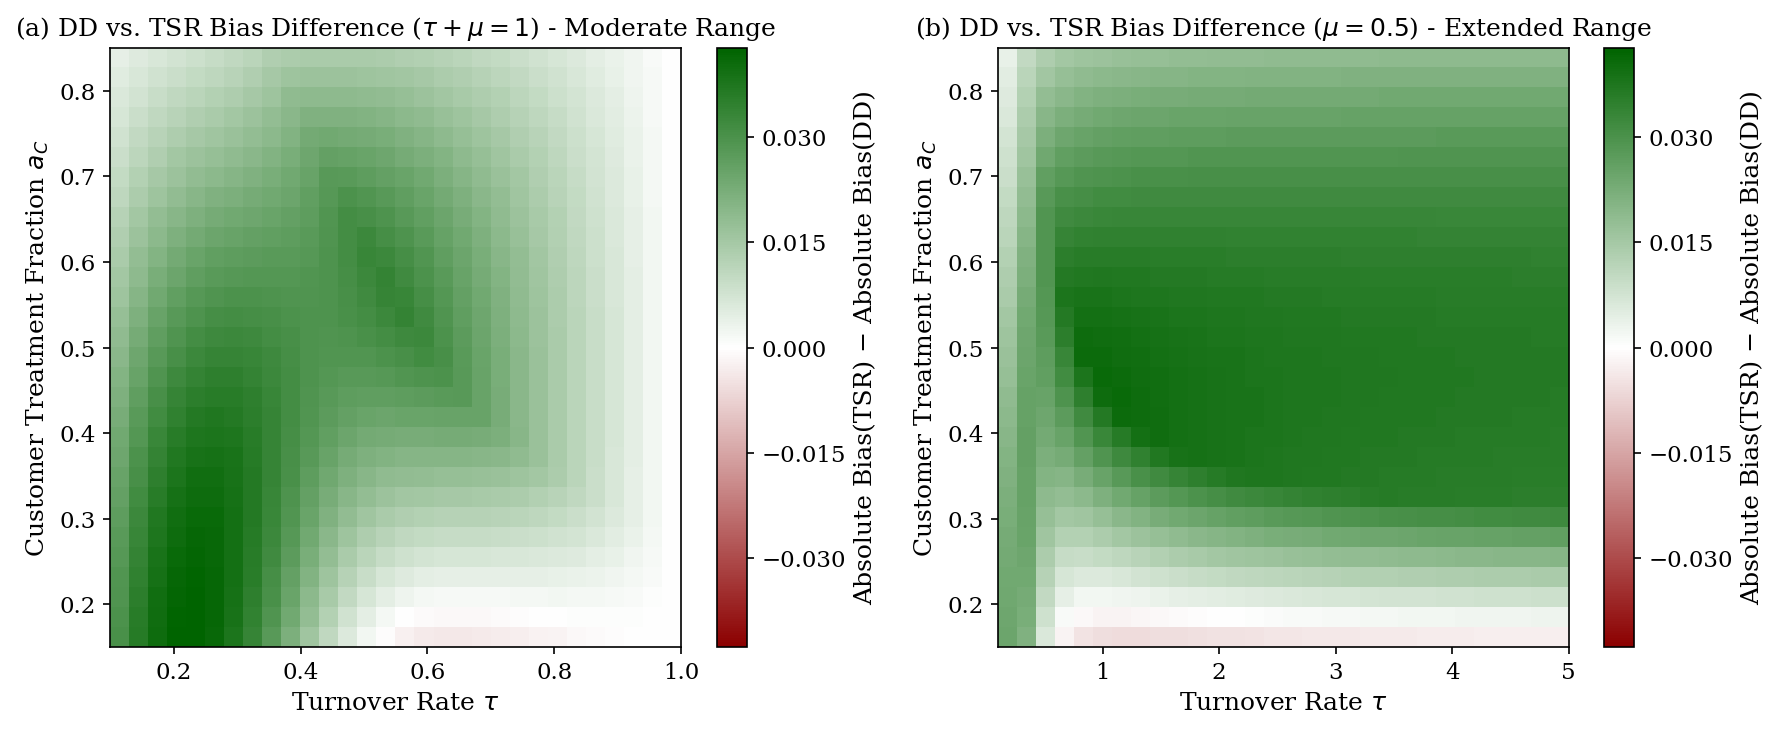

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.labelsize'] = 12
matplotlib.rcParams['axes.titlesize'] = 12
matplotlib.rcParams['figure.dpi'] = 150

# Base parameters
P_base = np.array([[0.1, 0.9], [0.9, 0.1], [0.2, 0.8]])
Ptilde_base = np.array([[0.5, 0.95], [0.95, 0.5], [0.6, 0.9]])
epsilon_base = np.array([0.2, 0.2, 0.2])
rho_base = np.array([0.3, 0.7])
phi_base = np.array([0.3, 0.3, 0.4])

tau_values_zoomed = np.linspace(0.1, 1.0, 30)
tau_values_extended = np.linspace(0.1, 5.0, 30)
aC_values = np.linspace(0.15, 0.85, 30)

# Generate data
data_zoomed_bias_diff = []
data_extended_bias_diff = []

for aC in aC_values:
    aL = 1 - aC
    row = []
    for tau in tau_values_zoomed:
        taus = np.array([tau, tau])
        mu = 1 - tau
        Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(
            aC, aL, Ptilde_base, P_base,
            epsilon_base, taus, mu, rho_base, phi_base
        )
        GTE_DD = (
            Q[1,1]/aL + Q[0,1]/aL
            - Q[1,0]/(1-aL) - Q[0,0]/(1-aL)
        )
        row.append(abs(GTE_TSR - GTE_true) - abs(GTE_DD - GTE_true))
    data_zoomed_bias_diff.append(row)

for aC in aC_values:
    aL = 1 - aC
    row = []
    for tau in tau_values_extended:
        taus = np.array([tau, tau])
        mu = 0.5
        Q, Qc, Qt, GTE_TSR, GTE_true = bias_analysis(
            aC, aL, Ptilde_base, P_base,
            epsilon_base, taus, mu, rho_base, phi_base
        )
        GTE_DD = (
            Q[1,1]/aL + Q[0,1]/aL
            - Q[1,0]/(1-aL) - Q[0,0]/(1-aL)
        )
        row.append(abs(GTE_TSR - GTE_true) - abs(GTE_DD - GTE_true))
    data_extended_bias_diff.append(row)

data_zoomed_bias_diff = np.array(data_zoomed_bias_diff)
data_extended_bias_diff = np.array(data_extended_bias_diff)

# Global symmetric normalization
global_min = min(data_zoomed_bias_diff.min(), data_extended_bias_diff.min())
global_max = max(data_zoomed_bias_diff.max(), data_extended_bias_diff.max())
M = max(abs(global_min), abs(global_max))

norm = Normalize(vmin=-M, vmax=M)

# Red–white–green colormap (no yellow bias)
cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["darkred", "white", "darkgreen"],
    N=256
)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(
    data_zoomed_bias_diff,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
    extent=[tau_values_zoomed[0], tau_values_zoomed[-1],
            aC_values[0], aC_values[-1]]
)

ax1.set_xlabel(r"Turnover Rate $\tau$ ")
ax1.set_ylabel(r"Customer Treatment Fraction $a_C$")
ax1.set_title(r"(a) DD vs. TSR Bias Difference ($\tau + \mu = 1$) - Moderate Range")

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label(r"Absolute Bias(TSR) − Absolute Bias(DD)")
cbar1.locator = MaxNLocator(nbins=7)
cbar1.update_ticks()

im2 = ax2.imshow(
    data_extended_bias_diff,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
    extent=[tau_values_extended[0], tau_values_extended[-1],
            aC_values[0], aC_values[-1]]
)

ax2.set_xlabel(r"Turnover Rate $\tau$")
ax2.set_ylabel(r"Customer Treatment Fraction $a_C$")
ax2.set_title(r"(b) DD vs. TSR Bias Difference ($\mu = 0.5$) - Extended Range")

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label(r"Absolute Bias(TSR) − Absolute Bias(DD)")
cbar2.locator = MaxNLocator(nbins=7)
cbar2.update_ticks()

plt.tight_layout()
plt.savefig("heatmap_dd_vs_tsr_bias_difference_continuous.pdf", dpi=300)
plt.savefig("heatmap_dd_vs_tsr_bias_difference_continuous.png", dpi=300)
plt.show()


In [67]:
import numpy as np
import pandas as pd

if 'df_plot' not in locals():
    if 'df_valid' in locals():
        df_plot = df_valid.copy()
        if 'Scenario' not in df_plot.columns:
            df_plot['Scenario'] = [f'S{i+1}' for i in range(len(df_plot))]
    else:
        print("df_plot and df_valid not found. Please run previous cells first.")

methods_other = ['TSR', 'TSRI1', 'TSRI2', 'CR', 'LR']

absolute_bias_differences = []
absolute_diff_colors = []

relative_bias_differences = []
relative_diff_colors = []

for _, row in df_plot.iterrows():
    bias_DD = abs(row['bias_DD'])

    min_other_bias = np.inf
    for m in methods_other:
        current_bias = abs(row[f'bias_{m}'])
        if current_bias < min_other_bias:
            min_other_bias = current_bias

    # A positive difference means DD has smaller absolute bias (DD wins, green)
    # A negative difference means Best Other has smaller absolute bias (DD loses, orange)
    abs_diff = min_other_bias - bias_DD
    absolute_bias_differences.append(abs_diff)

    if bias_DD < min_other_bias:
        absolute_diff_colors.append('green')
    else:
        absolute_diff_colors.append('orange')

    rel_bias_DD = abs(row['rel_bias_DD'])

    min_other_rel_bias = np.inf
    # Handle scenarios where 'GTE_true' is close to zero, causing 'rel_bias' to be NaN or Inf.
    # Filter out NaN/Inf values before finding the minimum.
    valid_other_rel_biases = []
    for m in methods_other:
        current_rel_bias_val = row[f'rel_bias_{m}']
        if pd.notna(current_rel_bias_val) and np.isfinite(current_rel_bias_val):
            valid_other_rel_biases.append(abs(current_rel_bias_val))

    if len(valid_other_rel_biases) > 0:
        min_other_rel_bias = min(valid_other_rel_biases)
    else:
        # If no valid other relative biases, consider DD as not superior to avoid division by zero or errors.
        min_other_rel_bias = rel_bias_DD # Set to DD's bias so DD won't win this comparison.

    rel_diff = min_other_rel_bias - rel_bias_DD
    relative_bias_differences.append(rel_diff)

    if rel_bias_DD < min_other_rel_bias:
        relative_diff_colors.append('green')
    else:
        relative_diff_colors.append('orange')

absolute_bias_differences = np.array(absolute_bias_differences)
relative_bias_differences = np.array(relative_bias_differences)

print("Data prepared for bias difference plots: absolute_bias_differences, absolute_diff_colors, relative_bias_differences, relative_diff_colors.")

Data prepared for bias difference plots: absolute_bias_differences, absolute_diff_colors, relative_bias_differences, relative_diff_colors.


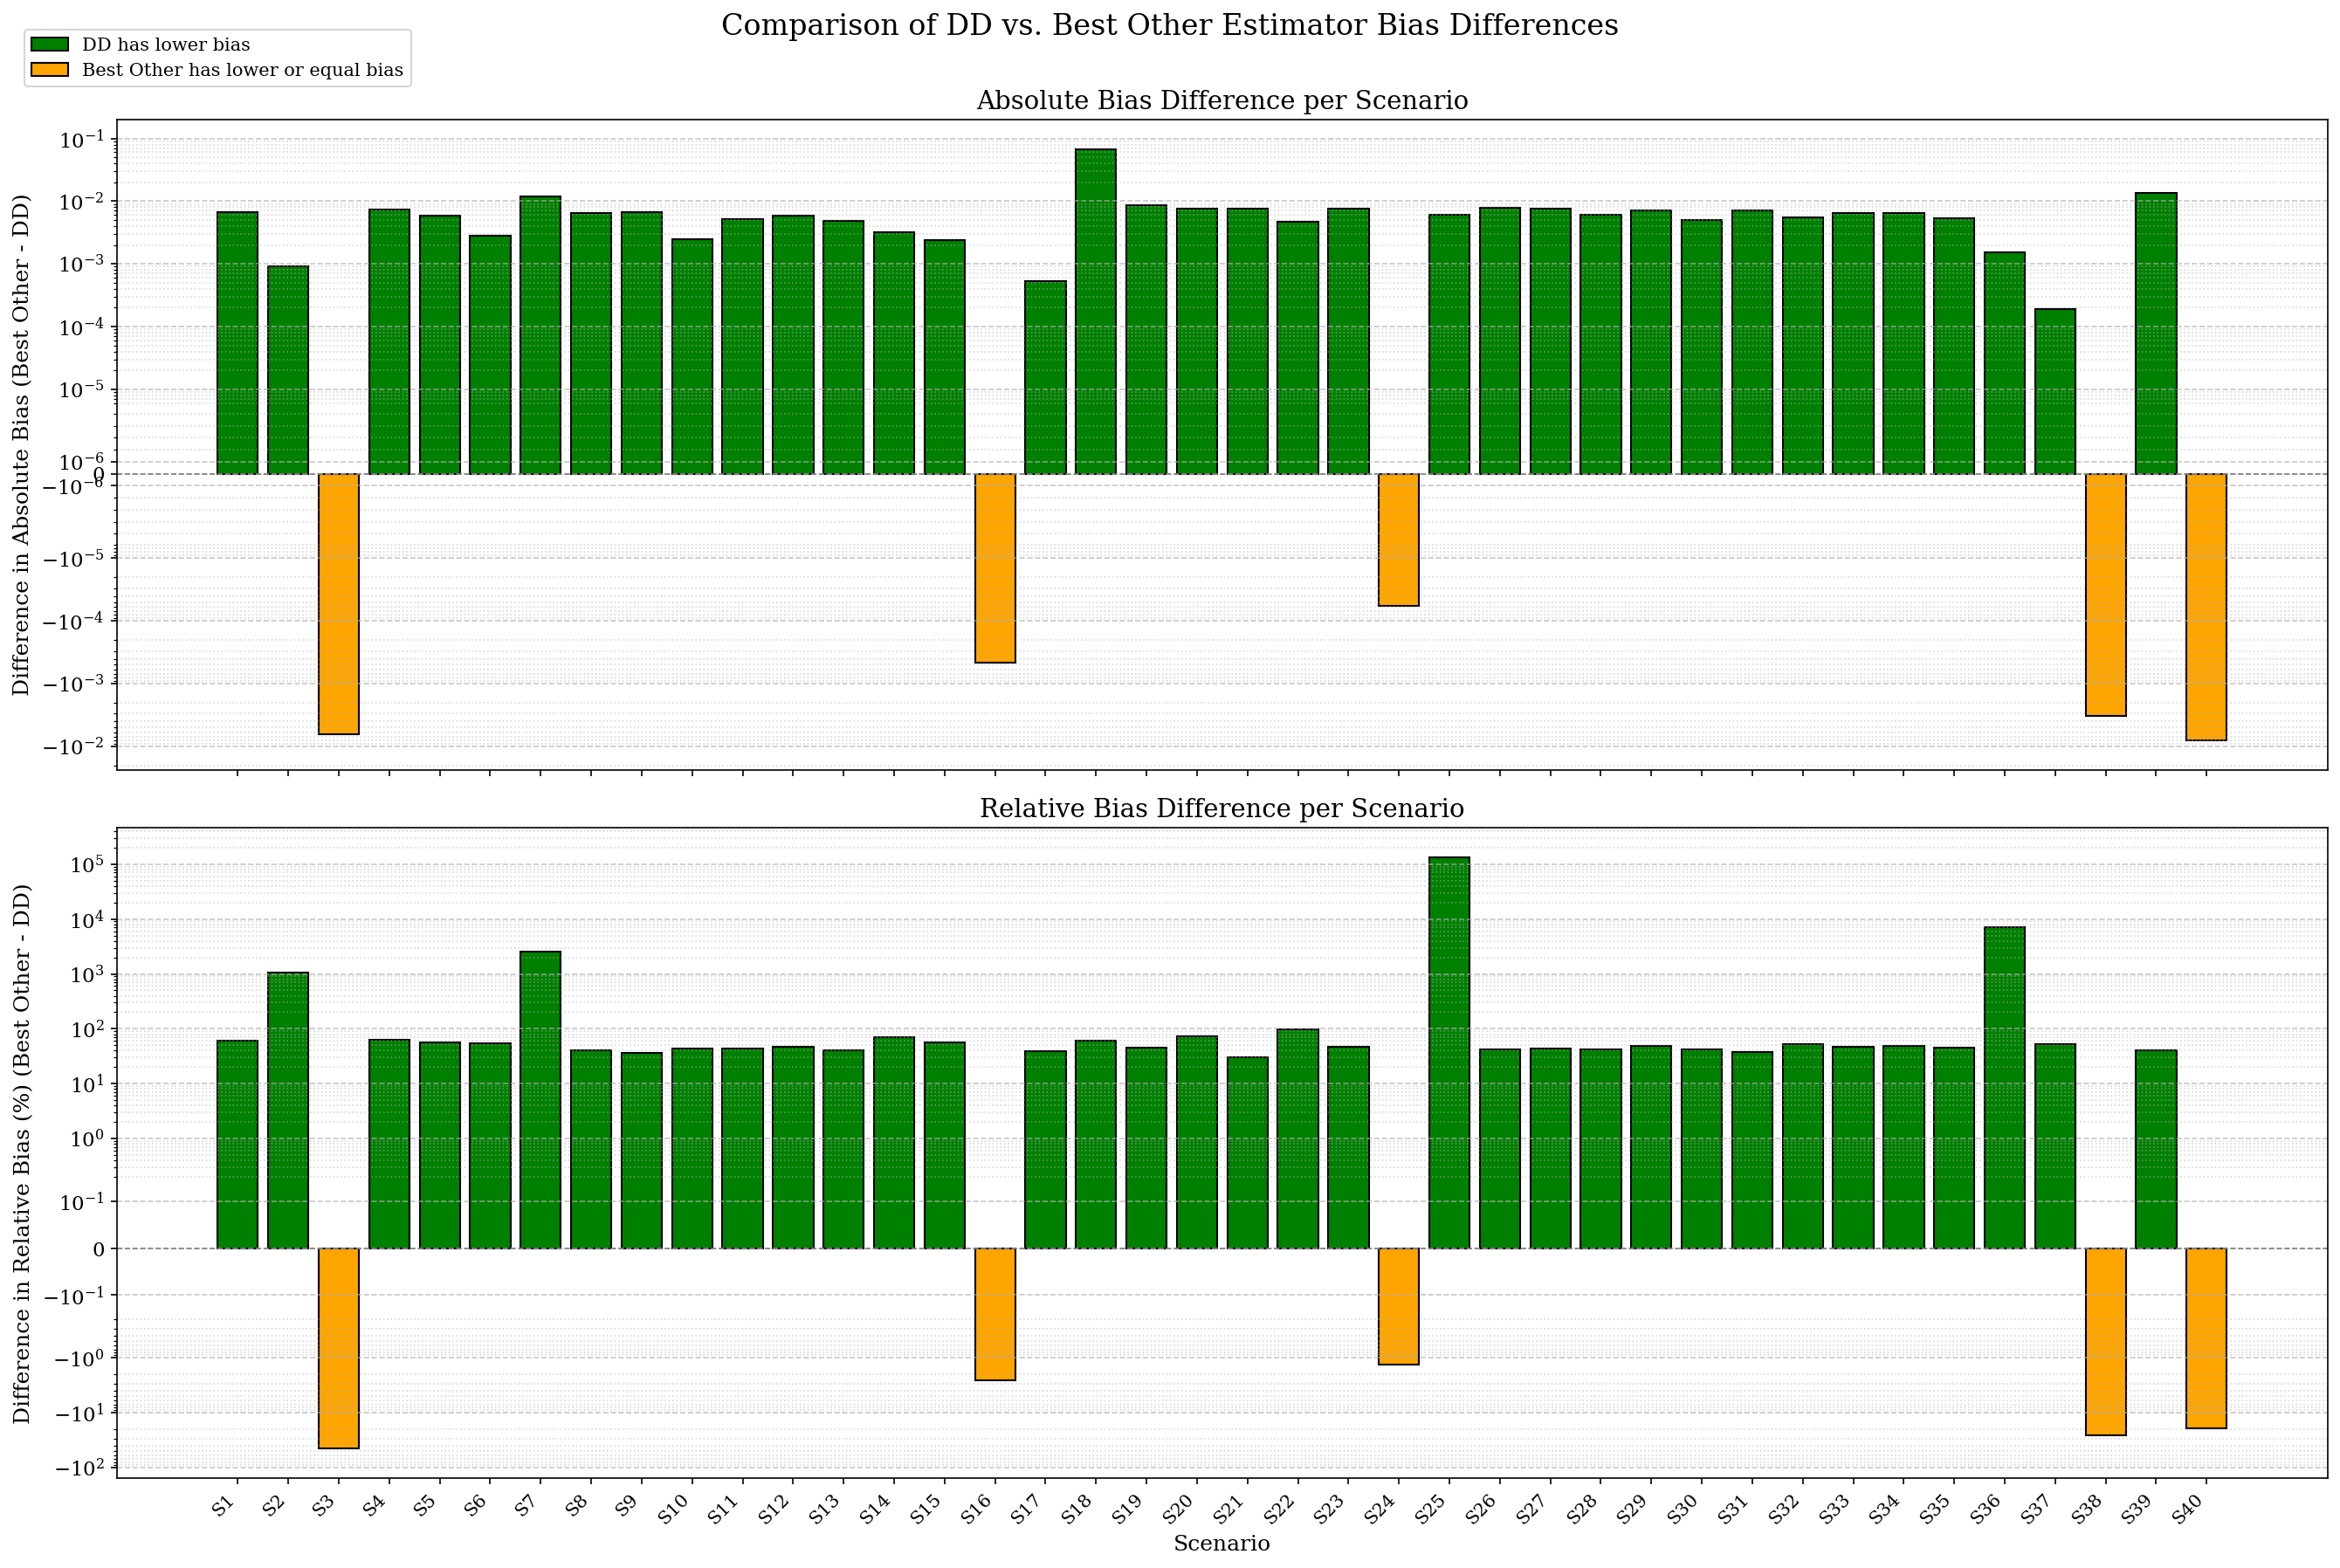

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import SymLogNorm

x = np.arange(len(scenario_labels))
width = 0.8 # Width of the bars

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Top Panel: Absolute Bias Differences
ax0 = axes[0]

abs_non_zero_abs_diffs = [abs(d) for d in absolute_bias_differences if d != 0]
linthresh_abs = 1e-6 if not abs_non_zero_abs_diffs else np.min(abs_non_zero_abs_diffs) * 0.1

ax0.bar(x, absolute_bias_differences, width, color=absolute_diff_colors, edgecolor='black')
ax0.set_ylabel('Difference in Absolute Bias (Best Other - DD)', fontsize=12)
ax0.set_title('Absolute Bias Difference per Scenario', fontsize=14)
ax0.set_yscale('symlog', linthresh=linthresh_abs, subs=[2, 3, 4, 5, 6, 7, 8, 9])
ax0.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax0.grid(axis='y', which='major', linestyle='--', alpha=0.7)
ax0.grid(axis='y', which='minor', linestyle=':', alpha=0.5)

# Bottom Panel: Relative Bias Differences
ax1 = axes[1]

abs_non_zero_rel_diffs = [abs(d) for d in relative_bias_differences if d != 0]
linthresh_rel = 1e-2 if not abs_non_zero_rel_diffs else np.min(abs_non_zero_rel_diffs) * 0.1

ax1.bar(x, relative_bias_differences, width, color=relative_diff_colors, edgecolor='black')
ax1.set_xlabel('Scenario', fontsize=12)
ax1.set_ylabel('Difference in Relative Bias (%) (Best Other - DD)', fontsize=12)
ax1.set_title('Relative Bias Difference per Scenario', fontsize=14)
ax1.set_yscale('symlog', linthresh=linthresh_rel, subs=[2, 3, 4, 5, 6, 7, 8, 9])
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(scenario_labels, rotation=45, ha='right', fontsize=10)
ax1.grid(axis='y', which='major', linestyle='--', alpha=0.7)
ax1.grid(axis='y', which='minor', linestyle=':', alpha=0.5)

legend_handles = [
    Patch(facecolor='green', edgecolor='black', label='DD has lower bias'),
    Patch(facecolor='orange', edgecolor='black', label='Best Other has lower or equal bias')
]
fig.legend(handles=legend_handles, fontsize=10, loc='upper left', bbox_to_anchor=(0.01, 0.99), bbox_transform=fig.transFigure)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle('Comparison of DD vs. Best Other Estimator Bias Differences', fontsize=16, y=0.995)
plt.show()